# Univariate and Bivariate Analysis of Application (Social Surrounding) Data
- table - application_train.csv
---

__Social surrounding of the client__:
- `OBS_30_CNT_SOCIAL_CIRCLE` - How many observation of client's social surroundings with observable 30 DPD (days past due) default
- `DEF_30_CNT_SOCIAL_CIRCLE` - How many observation of client's social surroundings defaulted on 30 DPD (days past due)
- `OBS_60_CNT_SOCIAL_CIRCLE` - How many observation of client's social surroundings with observable 60 DPD (days past due) default
- `DEF_60_CNT_SOCIAL_CIRCLE` - How many observation of client's social surroundings defaulted on 60 (days past due) DPD

## 0. Data and librarires

In [1]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / 'src'

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from eda_module import (
    plot_quantitative_distribution, plot_categorical_distribution, plot_binary_distribution, 
    plot_binary_vs_binary, plot_categorical_distribution, plot_quantitative_vs_binary,
    plot_categorical_vs_binary
)
from preprocess_module import (
    create_imputed_quantitative_features, filter_high_nans_cols, drop_obs_with_nans_in_low_nan_cols,
    trim_quantitative_var, cap_quantitative_var, categorical_target_summary
)

In [2]:
app_df = pd.read_csv(r"..\data\raw\application_train.csv")
print(f"Shape of app_df: {app_df.shape}")
app_df.head(10)

Shape of app_df: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
social_surrounding_cols = [
    'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE'
]
app_df[['TARGET'] + social_surrounding_cols].head()

,TARGET,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE
0,1,2.0,2.0,2.0,2.0
1,0,1.0,0.0,1.0,0.0
2,0,0.0,0.0,0.0,0.0
3,0,2.0,0.0,2.0,0.0
4,0,0.0,0.0,0.0,0.0


## 1. OBS_30_CNT_SOCIAL_CIRCLE
How many observation of client's social surroundings with observable 30 DPD (days past due) default

In [6]:
print(app_df['OBS_30_CNT_SOCIAL_CIRCLE'].describe())
print(f"NANs: {app_df['OBS_30_CNT_SOCIAL_CIRCLE'].isna().sum()}")

count    306490.000000
mean          1.422245
std           2.400989
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         348.000000
Name: OBS_30_CNT_SOCIAL_CIRCLE, dtype: float64
NANs: 1021


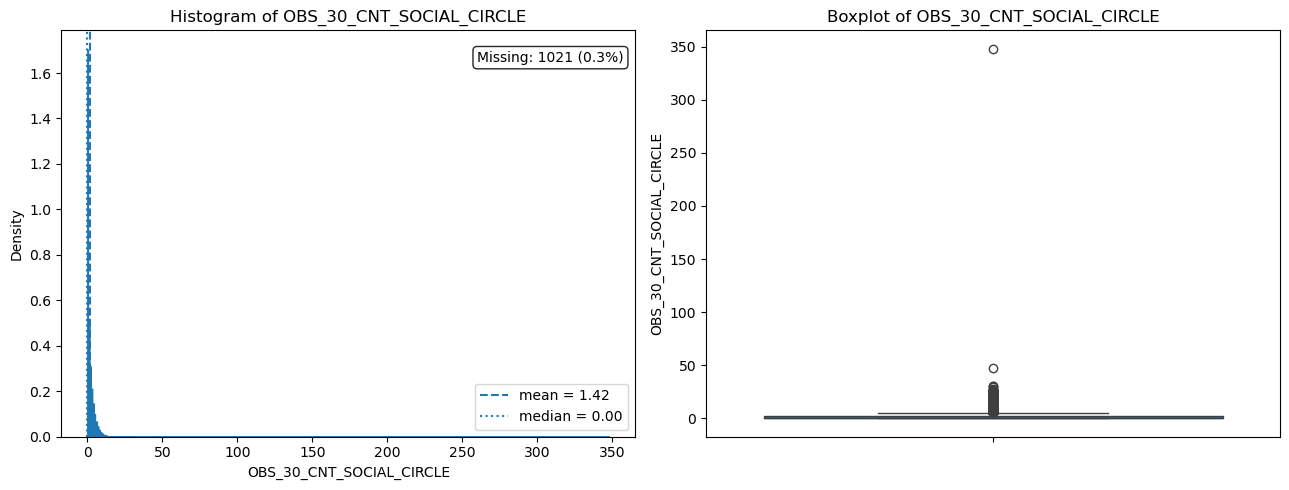

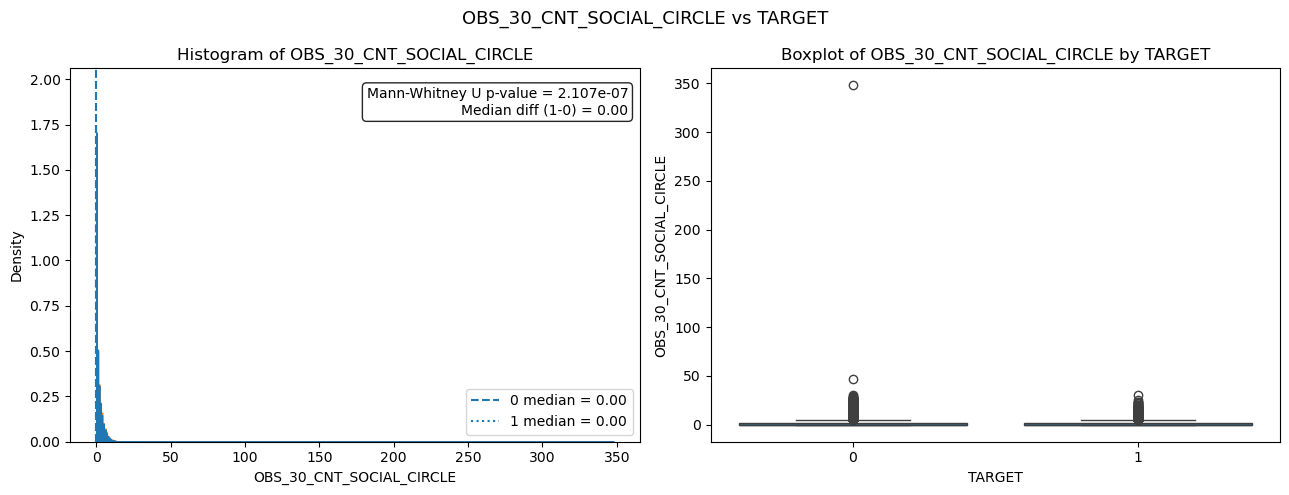

In [7]:
plot_quantitative_distribution(df=app_df, quant_var='OBS_30_CNT_SOCIAL_CIRCLE')
plot_quantitative_vs_binary(df=app_df, quant_var='OBS_30_CNT_SOCIAL_CIRCLE', binary_var='TARGET')

In [8]:
app_df[app_df['OBS_30_CNT_SOCIAL_CIRCLE'] == 348]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
148403,272071,0,Revolving loans,M,N,Y,0,202500.0,180000.0,9000.0,...,0,0,0,0,0.0,0.0,1.0,1.0,0.0,3.0


In [9]:
print(app_df[app_df['OBS_30_CNT_SOCIAL_CIRCLE'] < 348]['OBS_30_CNT_SOCIAL_CIRCLE'].describe())
print(f"NANs: {app_df['OBS_30_CNT_SOCIAL_CIRCLE'].isna().sum()}")

count    306489.000000
mean          1.421115
std           2.317942
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          47.000000
Name: OBS_30_CNT_SOCIAL_CIRCLE, dtype: float64
NANs: 1021


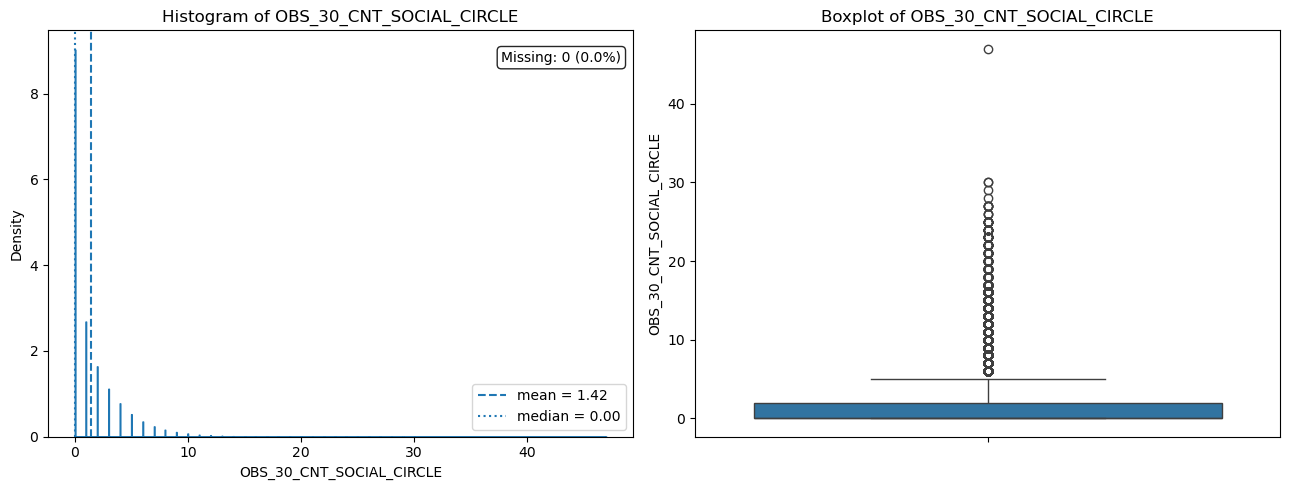

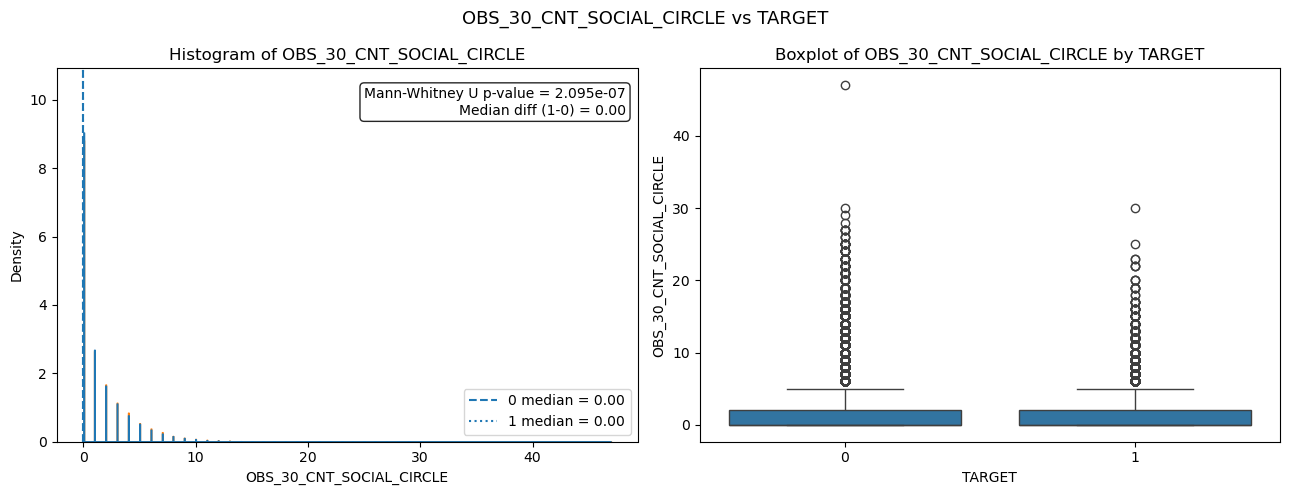

In [10]:
plot_quantitative_distribution(df=app_df[app_df['OBS_30_CNT_SOCIAL_CIRCLE'] < 348], quant_var='OBS_30_CNT_SOCIAL_CIRCLE')
plot_quantitative_vs_binary(df=app_df[app_df['OBS_30_CNT_SOCIAL_CIRCLE'] < 348], quant_var='OBS_30_CNT_SOCIAL_CIRCLE', binary_var='TARGET')

In [32]:
app_df['OBS_30_CNT_SOCIAL_CIRCLE_missing'] = np.where(app_df['OBS_30_CNT_SOCIAL_CIRCLE'].isna(), 1, 0)
app_df['OBS_30_CNT_SOCIAL_CIRCLE_missing'].value_counts()

OBS_30_CNT_SOCIAL_CIRCLE_missing
0    306490
1      1021
Name: count, dtype: int64

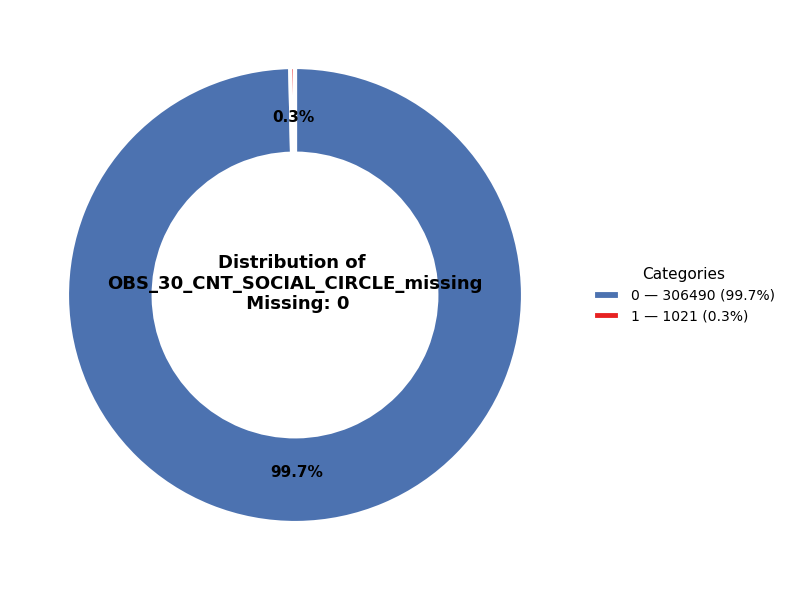

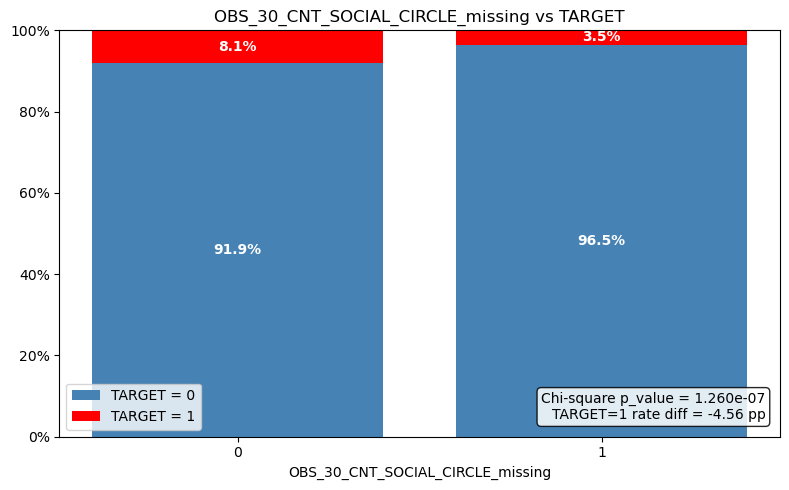

In [33]:
plot_binary_distribution(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_missing')
plot_binary_vs_binary(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_missing', target_var='TARGET')

In [19]:
app_df['OBS_30_CNT_SOCIAL_CIRCLE_ge_10'] = np.where(
    app_df['OBS_30_CNT_SOCIAL_CIRCLE'] >= 10, 1, 0
)
app_df['OBS_30_CNT_SOCIAL_CIRCLE_ge_10'].value_counts()

OBS_30_CNT_SOCIAL_CIRCLE_ge_10
0    303353
1      4158
Name: count, dtype: int64

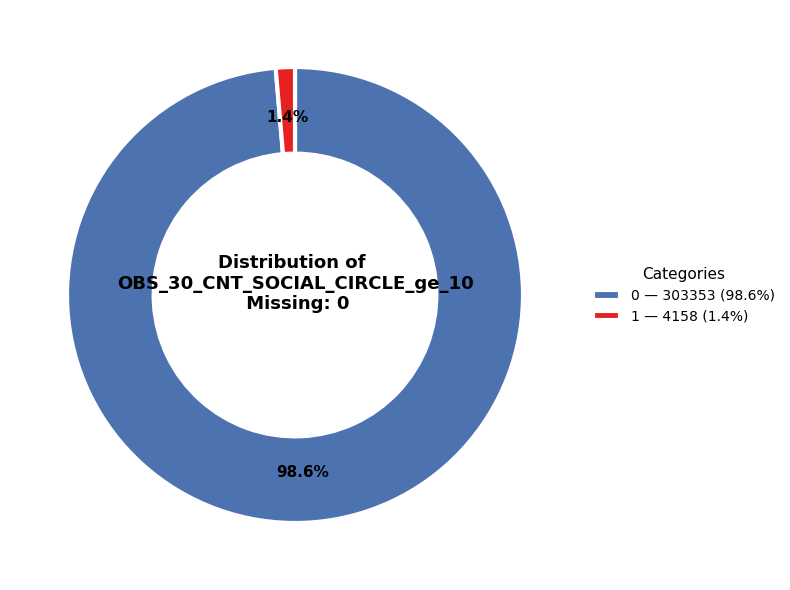

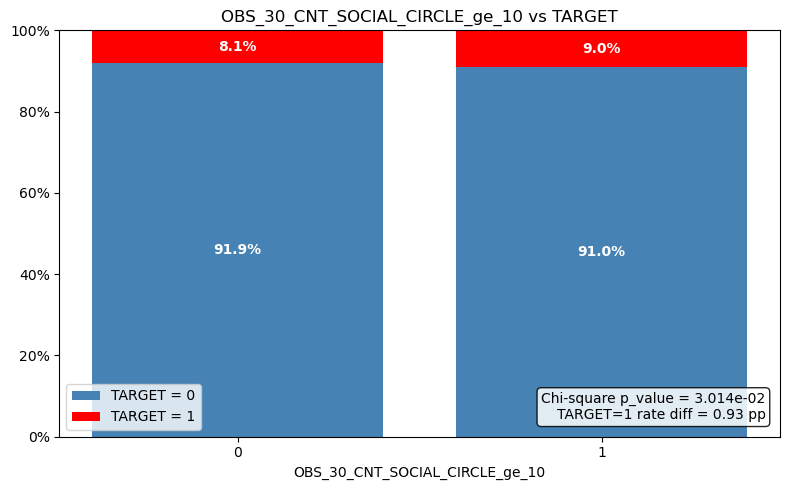

In [20]:
plot_binary_distribution(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_ge_10')
plot_binary_vs_binary(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_ge_10', target_var='TARGET')

In [ ]:
app_df['OBS_30_CNT_SOCIAL_CIRCLE_eq_0'] = np.where(
    app_df['OBS_30_CNT_SOCIAL_CIRCLE'] > 0, 1, 0
)
app_df['OBS_30_CNT_SOCIAL_CIRCLE_eq_0'].value_counts()

OBS_30_CNT_SOCIAL_CIRCLE_eq_0
1    163910
0    143601
Name: count, dtype: int64

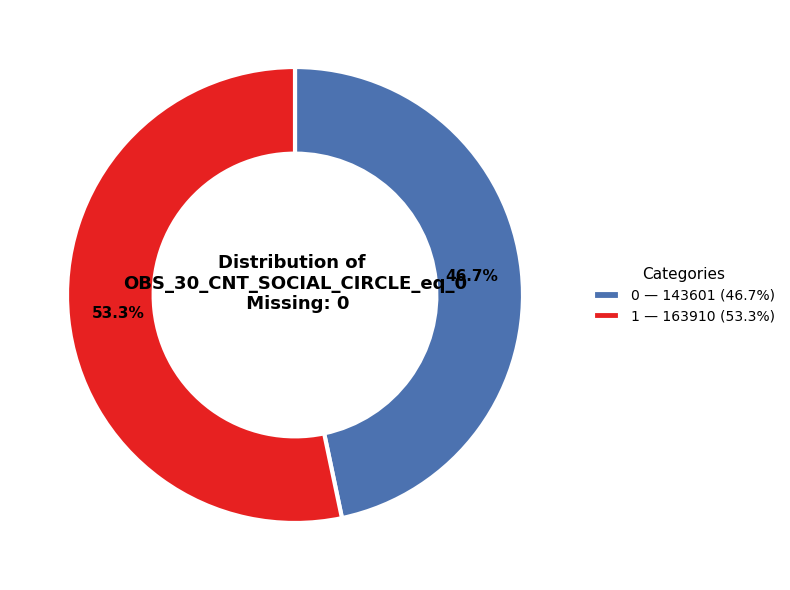

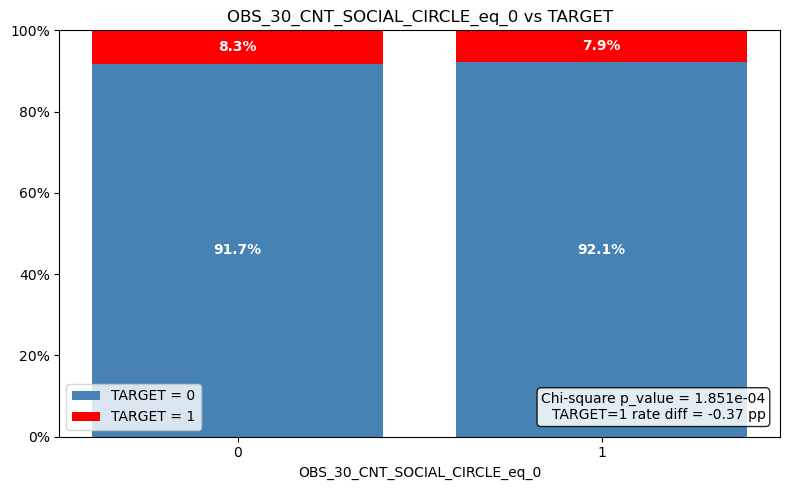

In [22]:
plot_binary_distribution(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_eq_0')
plot_binary_vs_binary(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_eq_0', target_var='TARGET')

In [34]:
app_df["OBS_30_CNT_SOCIAL_CIRCLE_ge_3"] = (app_df["OBS_30_CNT_SOCIAL_CIRCLE"] >= 3).astype(int)
app_df["OBS_30_CNT_SOCIAL_CIRCLE_ge_5"] = (app_df["OBS_30_CNT_SOCIAL_CIRCLE"] >= 5).astype(int)
app_df["OBS_30_CNT_SOCIAL_CIRCLE_ge_7"] = (app_df["OBS_30_CNT_SOCIAL_CIRCLE"] >= 7).astype(int)
app_df["OBS_30_CNT_SOCIAL_CIRCLE_ge_9"] = (app_df["OBS_30_CNT_SOCIAL_CIRCLE"] >= 9).astype(int)
app_df["OBS_30_CNT_SOCIAL_CIRCLE_ge_8"] = (app_df["OBS_30_CNT_SOCIAL_CIRCLE"] >= 8).astype(int)

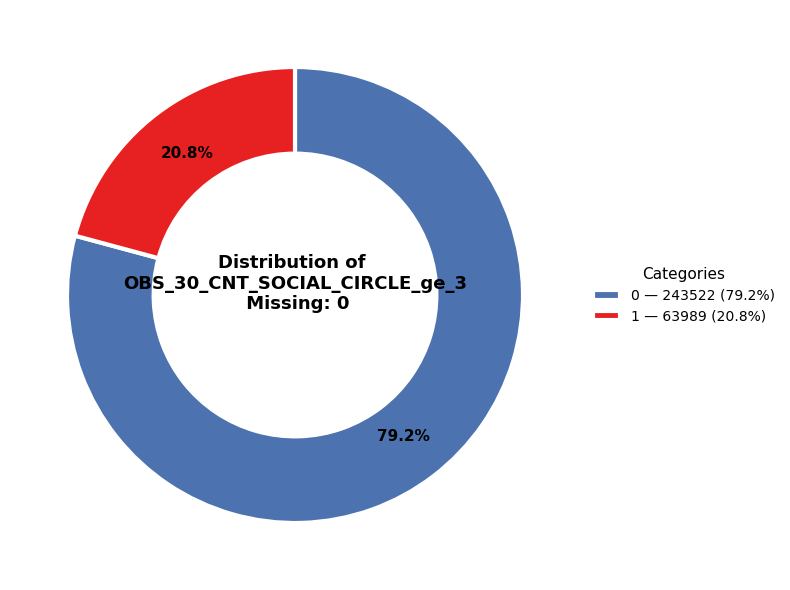

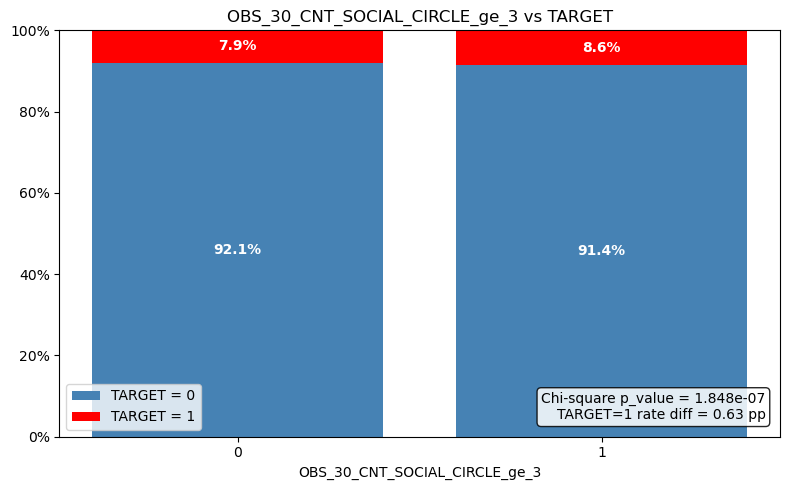

In [ ]:
plot_binary_distribution(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_ge_3')
plot_binary_vs_binary(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_ge_3', target_var='TARGET')

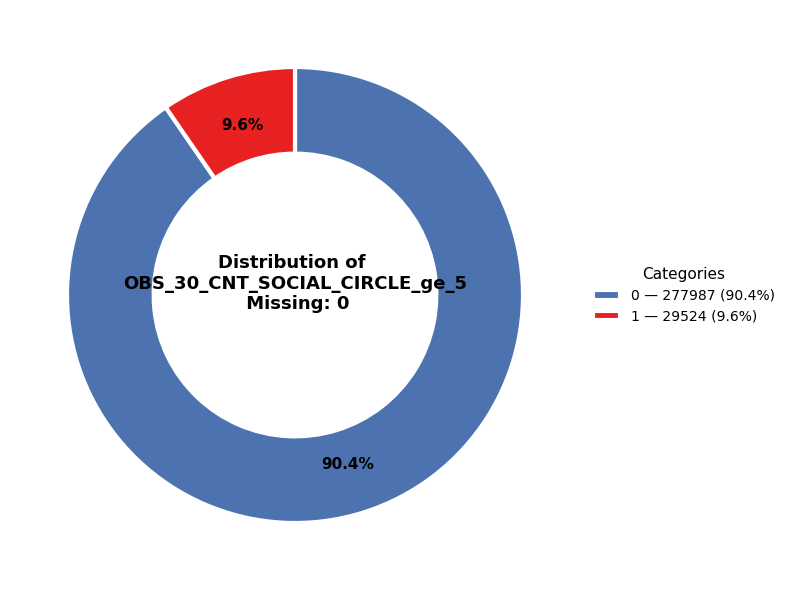

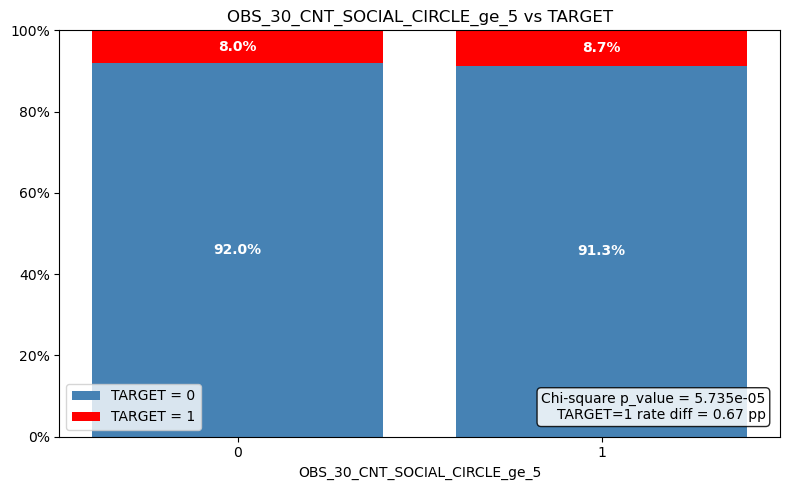

In [26]:
plot_binary_distribution(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_ge_5')
plot_binary_vs_binary(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_ge_5', target_var='TARGET')

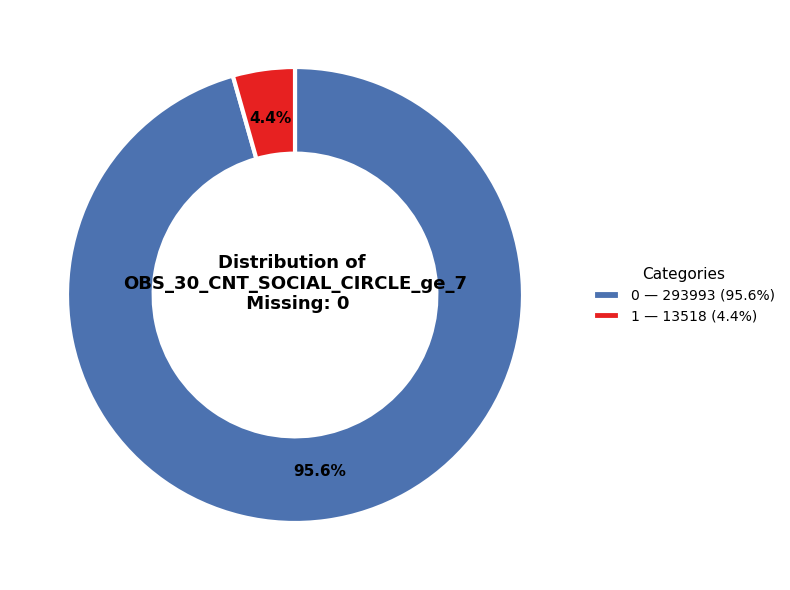

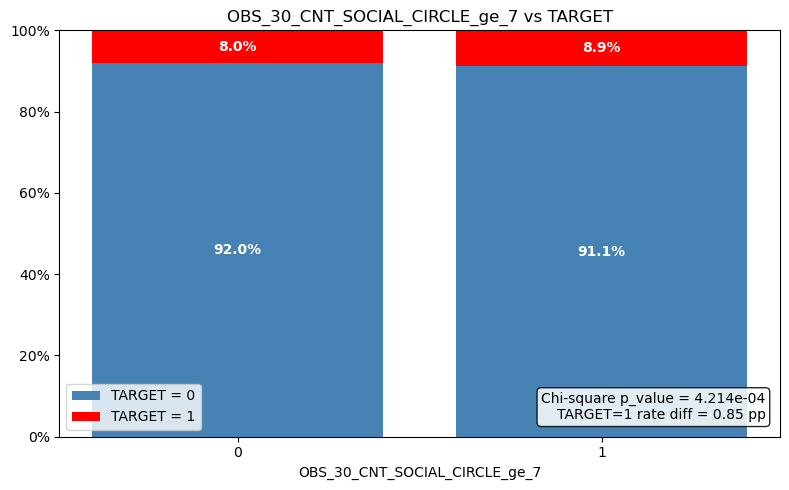

In [28]:
plot_binary_distribution(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_ge_7')
plot_binary_vs_binary(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_ge_7', target_var='TARGET')

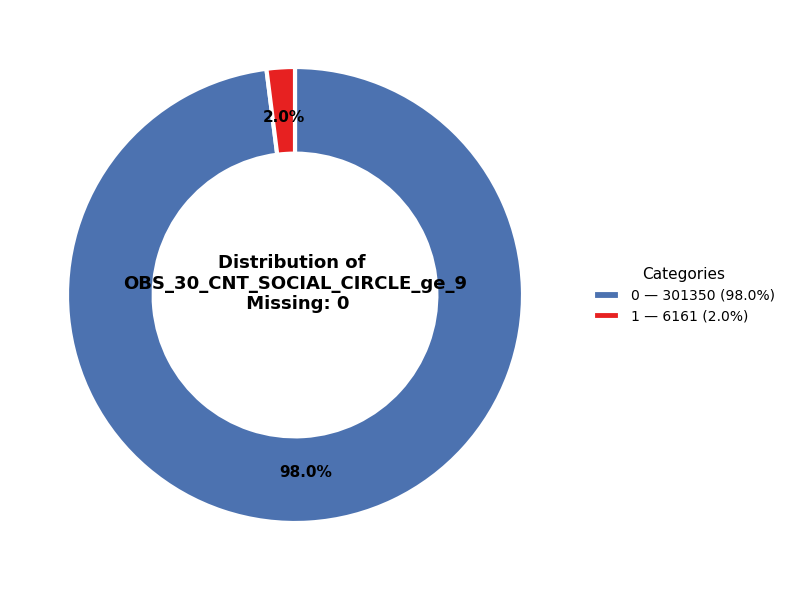

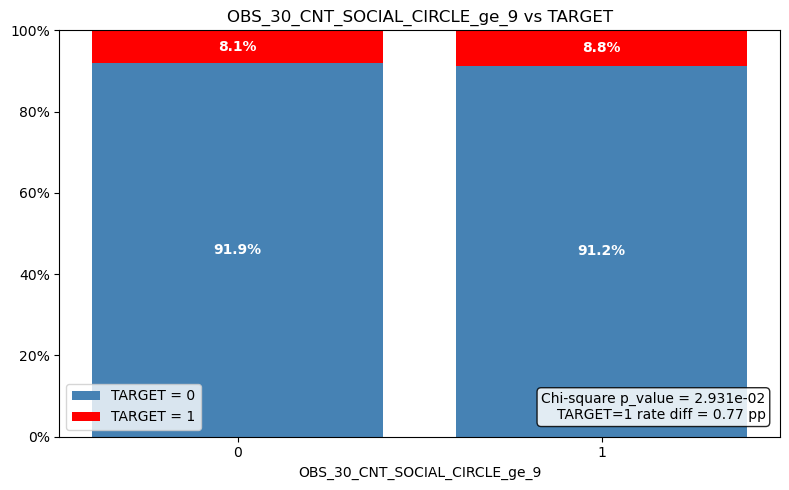

In [31]:
plot_binary_distribution(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_ge_9')
plot_binary_vs_binary(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_ge_9', target_var='TARGET')

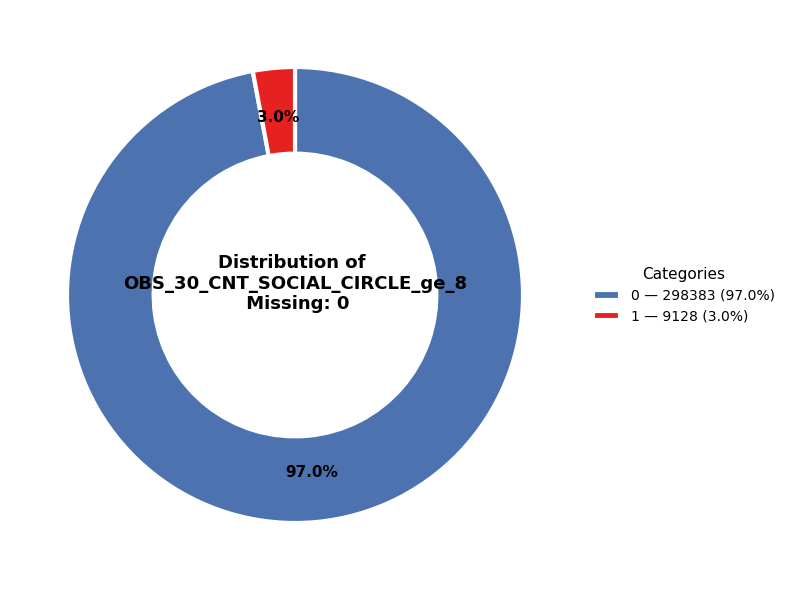

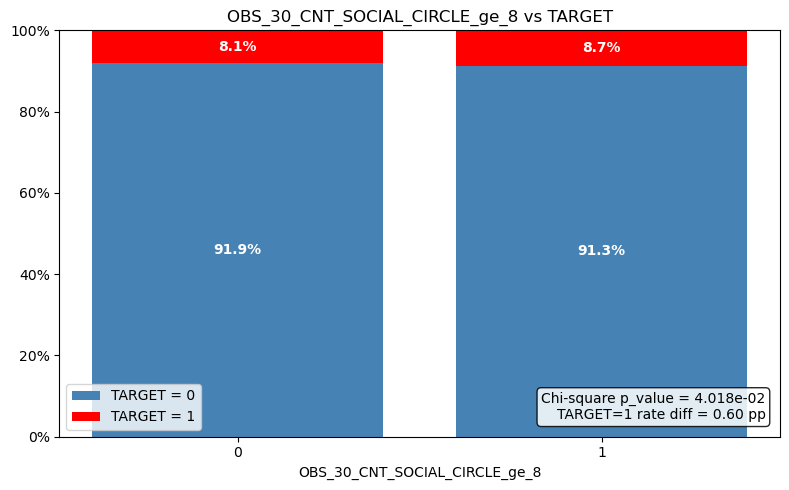

In [35]:
plot_binary_distribution(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_ge_8')
plot_binary_vs_binary(df=app_df, binary_var='OBS_30_CNT_SOCIAL_CIRCLE_ge_8', target_var='TARGET')

In [39]:
app_df['OBS_30_CNT_SOCIAL_CIRCLE_imp_global'] = app_df['OBS_30_CNT_SOCIAL_CIRCLE'].fillna(app_df['OBS_30_CNT_SOCIAL_CIRCLE'].median())

In [ ]:
app_df["OBS_30_CNT_SOCIAL_CIRCLE_imp_global_cap_7"] = app_df["OBS_30_CNT_SOCIAL_CIRCLE_imp_global"].clip(upper=7)
app_df["OBS_30_CNT_SOCIAL_CIRCLE_imp_global_cap_10"] = app_df["OBS_30_CNT_SOCIAL_CIRCLE_imp_global"].clip(upper=10)

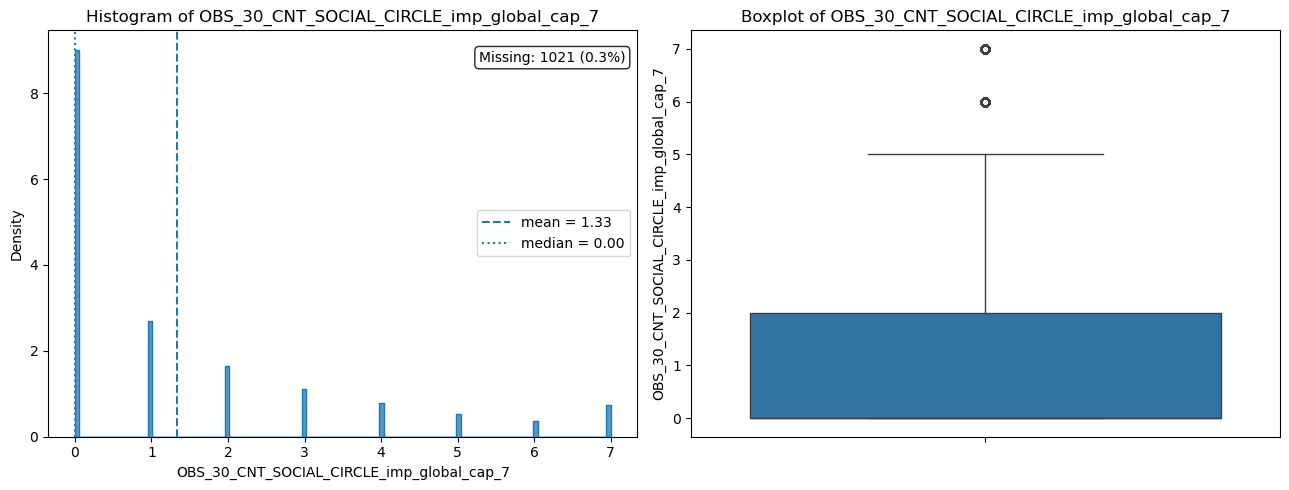

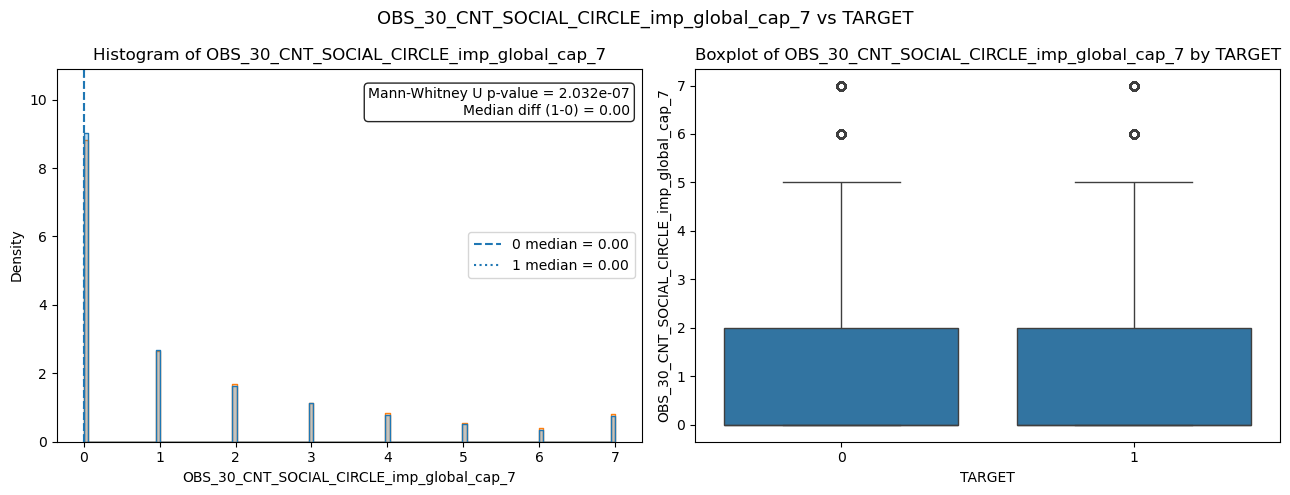

In [41]:
plot_quantitative_distribution(df=app_df, quant_var='OBS_30_CNT_SOCIAL_CIRCLE_imp_global_cap_7')
plot_quantitative_vs_binary(df=app_df, quant_var='OBS_30_CNT_SOCIAL_CIRCLE_imp_global_cap_7', binary_var='TARGET')

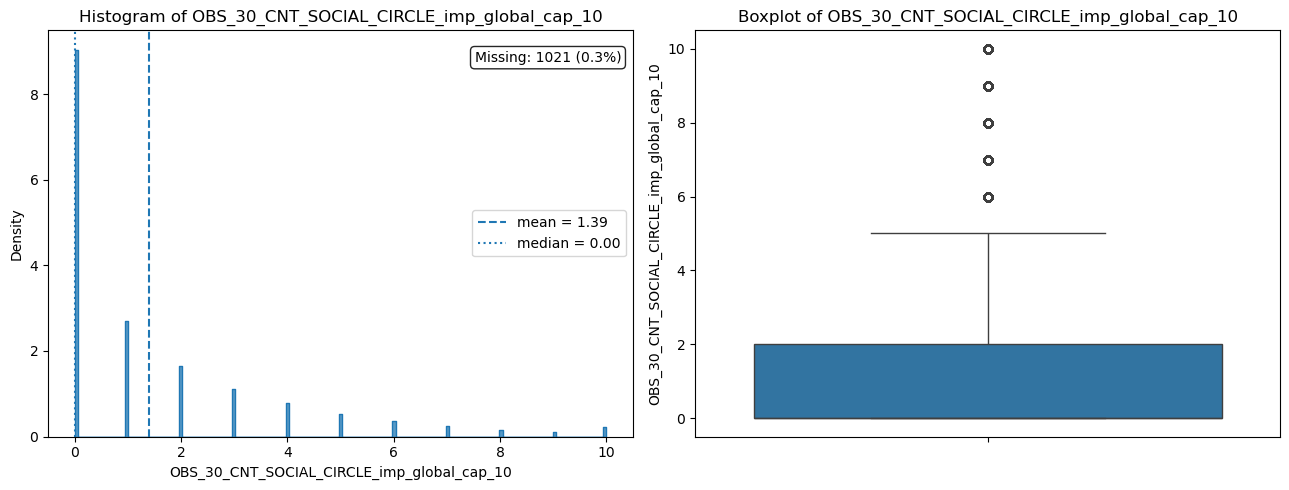

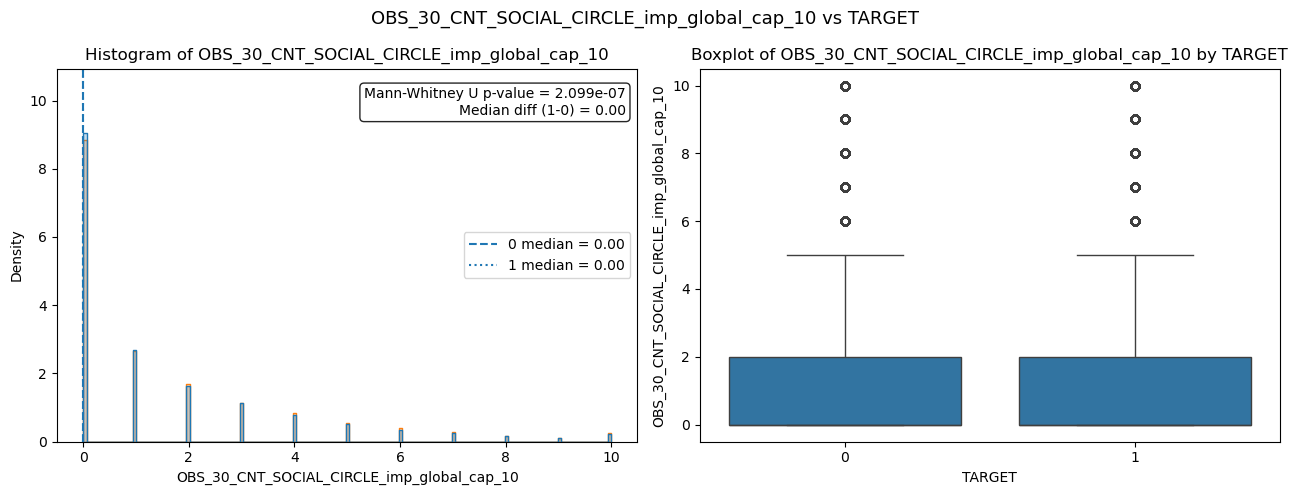

In [43]:
plot_quantitative_distribution(df=app_df, quant_var='OBS_30_CNT_SOCIAL_CIRCLE_imp_global_cap_10')
plot_quantitative_vs_binary(df=app_df, quant_var='OBS_30_CNT_SOCIAL_CIRCLE_imp_global_cap_10', binary_var='TARGET')

In [73]:
app_df['OBS_30_CNT_SOCIAL_CIRCLE_cap_cat'] = np.where(
    app_df['OBS_30_CNT_SOCIAL_CIRCLE'].isin([0,1,2,3,4,5,6]),
    app_df['OBS_30_CNT_SOCIAL_CIRCLE'].astype(str),
    np.where(
        app_df['DEF_30_CNT_SOCIAL_CIRCLE'].isna(),
        'Missing',
        '>= 7'
    )
)

app_df['OBS_30_CNT_SOCIAL_CIRCLE_cap_cat'].value_counts()

OBS_30_CNT_SOCIAL_CIRCLE_cap_cat
0.0        163910
1.0         48783
2.0         29808
3.0         20322
4.0         14143
>= 7        13518
5.0          9553
6.0          6453
Missing      1021
Name: count, dtype: int64

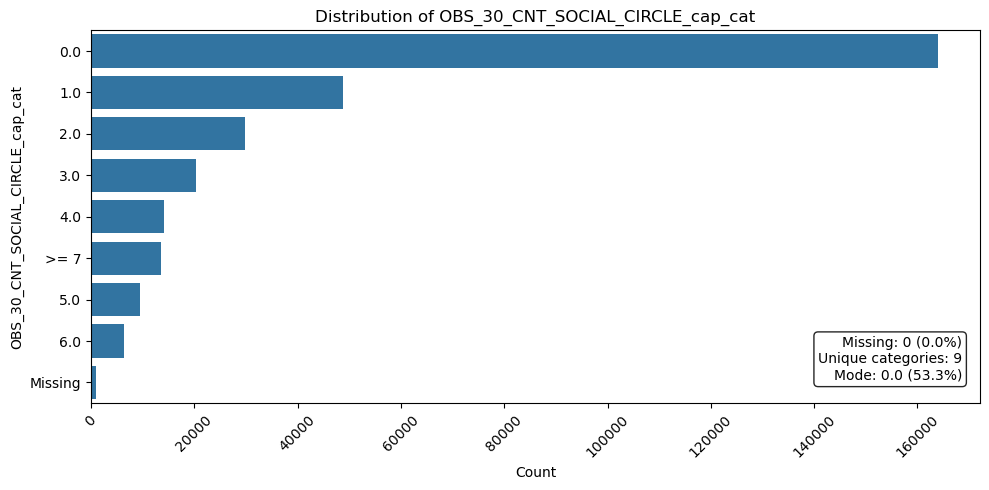

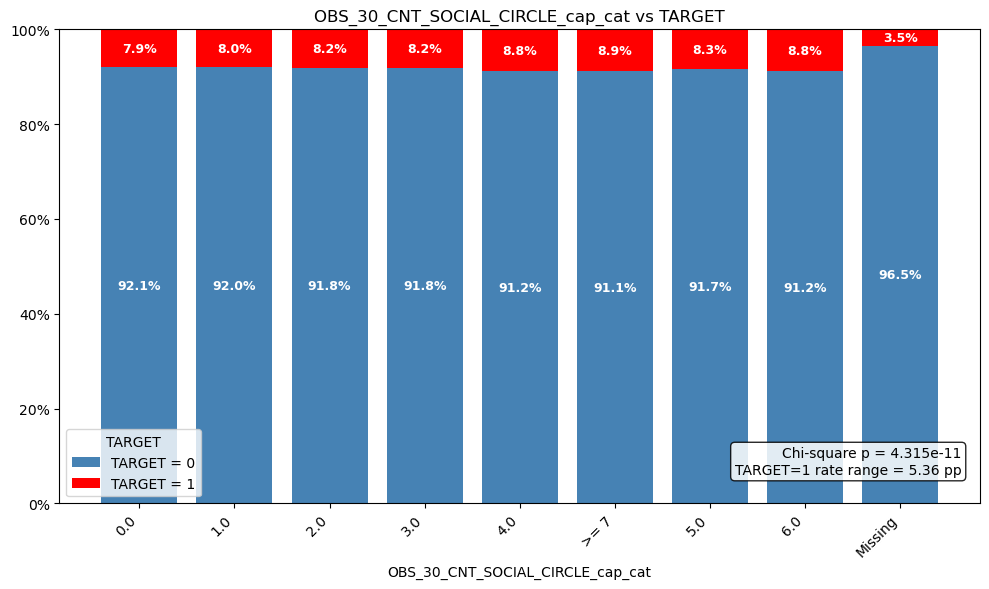

In [74]:
plot_categorical_distribution(df=app_df, cat_var='OBS_30_CNT_SOCIAL_CIRCLE_cap_cat')
plot_categorical_vs_binary(df=app_df, cat_var='OBS_30_CNT_SOCIAL_CIRCLE_cap_cat', target_var='TARGET')

In [75]:
app_df['OBS_30_CNT_SOCIAL_CIRCLE_cap_cat'] = np.where(
    app_df['OBS_30_CNT_SOCIAL_CIRCLE'] == 0,
    '0',
    np.where(
         app_df['OBS_30_CNT_SOCIAL_CIRCLE'].isin([1,2,3]),
        '1-3',
        np.where(
            app_df['DEF_30_CNT_SOCIAL_CIRCLE'].isna(),
            'Missing',
            np.where(
                app_df['OBS_30_CNT_SOCIAL_CIRCLE'] >= 4,
                '>= 4',
                'Invalid'
            )
        )
    )
)


app_df['OBS_30_CNT_SOCIAL_CIRCLE_cap_cat'].value_counts()

OBS_30_CNT_SOCIAL_CIRCLE_cap_cat
0          163910
1-3         98913
>= 4        43667
Missing      1021
Name: count, dtype: int64

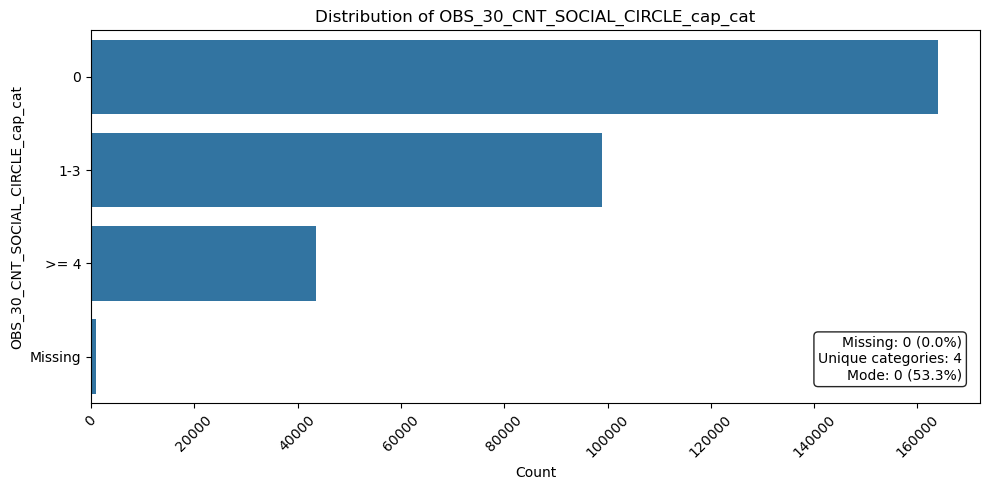

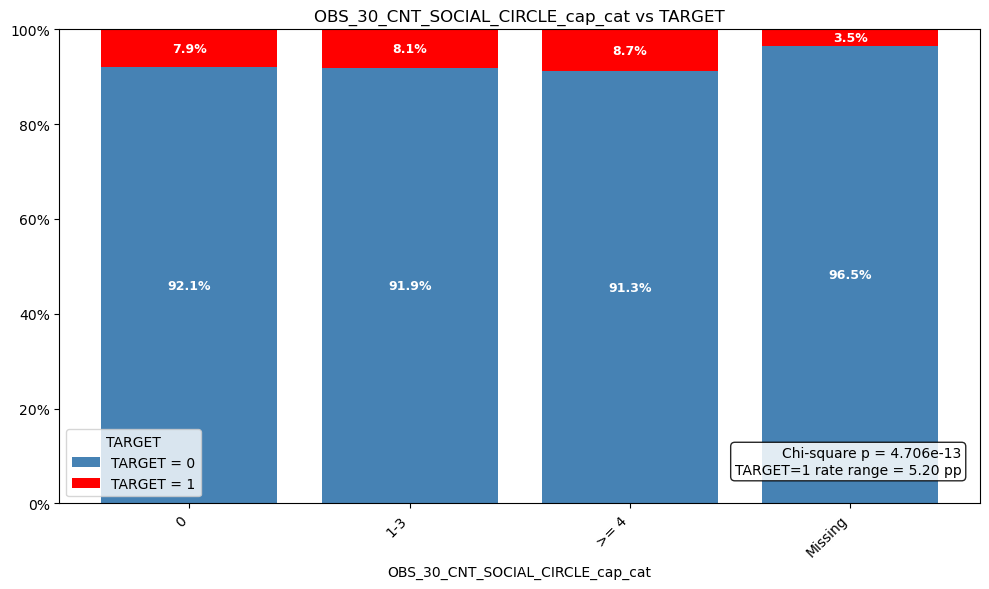

In [76]:
plot_categorical_distribution(df=app_df, cat_var='OBS_30_CNT_SOCIAL_CIRCLE_cap_cat')
plot_categorical_vs_binary(df=app_df, cat_var='OBS_30_CNT_SOCIAL_CIRCLE_cap_cat', target_var='TARGET')

In [99]:
app_df['OBS_30_CNT_SOCIAL_CIRCLE_imp_global_cap'] = np.where(
    app_df['OBS_30_CNT_SOCIAL_CIRCLE'].isin([0,1,2,3]),
    app_df['OBS_30_CNT_SOCIAL_CIRCLE'],
    np.where(
        app_df['OBS_30_CNT_SOCIAL_CIRCLE'] >= 2,
        2.0,
        np.where(
            app_df['OBS_30_CNT_SOCIAL_CIRCLE'].isna(),
            app_df['OBS_30_CNT_SOCIAL_CIRCLE'].median(),
            999.0
        )
    )
)
app_df['OBS_30_CNT_SOCIAL_CIRCLE_imp_global_cap'].value_counts()

OBS_30_CNT_SOCIAL_CIRCLE_imp_global_cap
0.0    164931
2.0     73475
1.0     48783
3.0     20322
Name: count, dtype: int64

Both versions - categorical and imputed_capped version will be used in modeling
- both can be used in tree-based models
- the categorical version can be superior for logistic regression

## 2. DEF_30_CNT_SOCIAL_CIRCLE
How many observation of client's social surroundings defaulted on 30 DPD (days past due)

In [59]:
print(app_df['DEF_30_CNT_SOCIAL_CIRCLE'].describe())
print(f"NANs: {app_df['DEF_30_CNT_SOCIAL_CIRCLE'].isna().sum()}")
print(app_df['DEF_30_CNT_SOCIAL_CIRCLE'].value_counts())

count    306490.000000
mean          0.143421
std           0.446698
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          34.000000
Name: DEF_30_CNT_SOCIAL_CIRCLE, dtype: float64
NANs: 1021
DEF_30_CNT_SOCIAL_CIRCLE
0.0     271324
1.0      28328
2.0       5323
3.0       1192
4.0        253
5.0         56
6.0         11
7.0          1
34.0         1
8.0          1
Name: count, dtype: int64


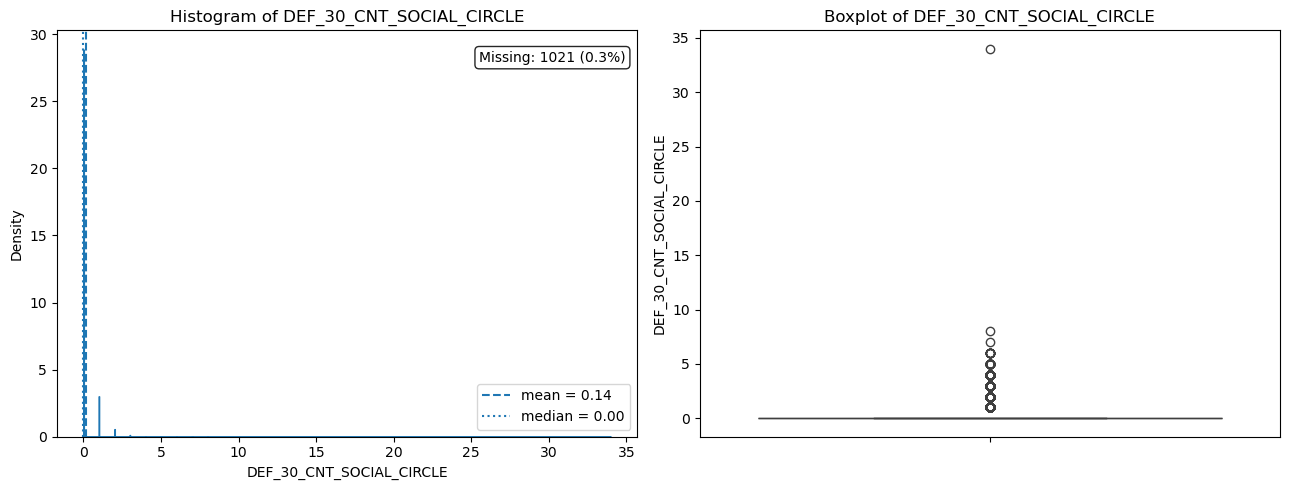

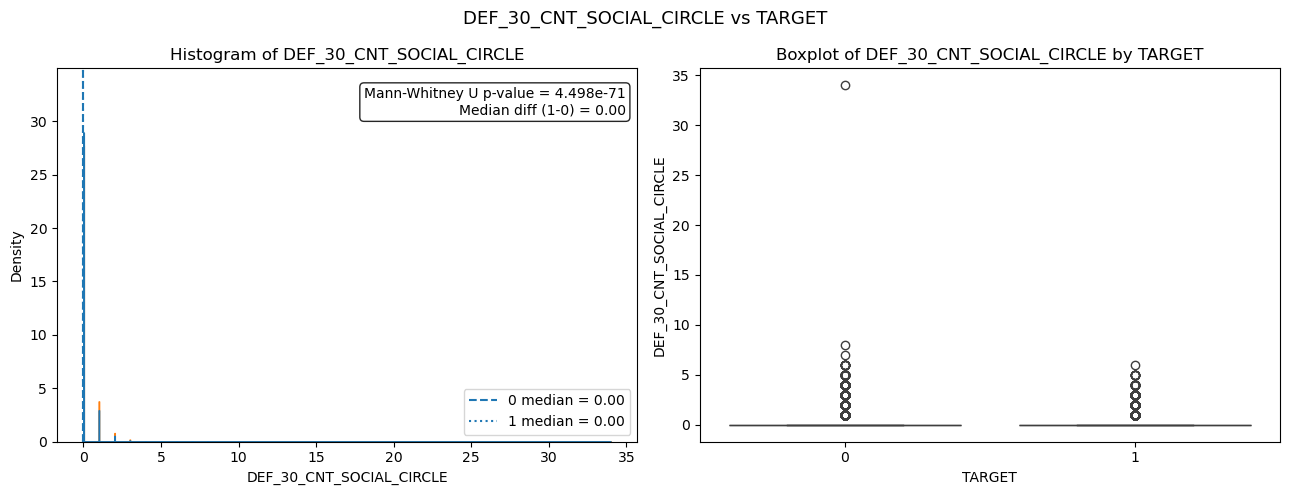

In [47]:
plot_quantitative_distribution(df=app_df, quant_var='DEF_30_CNT_SOCIAL_CIRCLE')
plot_quantitative_vs_binary(df=app_df, quant_var='DEF_30_CNT_SOCIAL_CIRCLE', binary_var='TARGET')

In [48]:
print(app_df[app_df['DEF_30_CNT_SOCIAL_CIRCLE'] < 34]['DEF_30_CNT_SOCIAL_CIRCLE'].describe())
print(app_df['DEF_30_CNT_SOCIAL_CIRCLE'].isna().sum())

count    306489.000000
mean          0.143310
std           0.442493
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           8.000000
Name: DEF_30_CNT_SOCIAL_CIRCLE, dtype: float64
1021


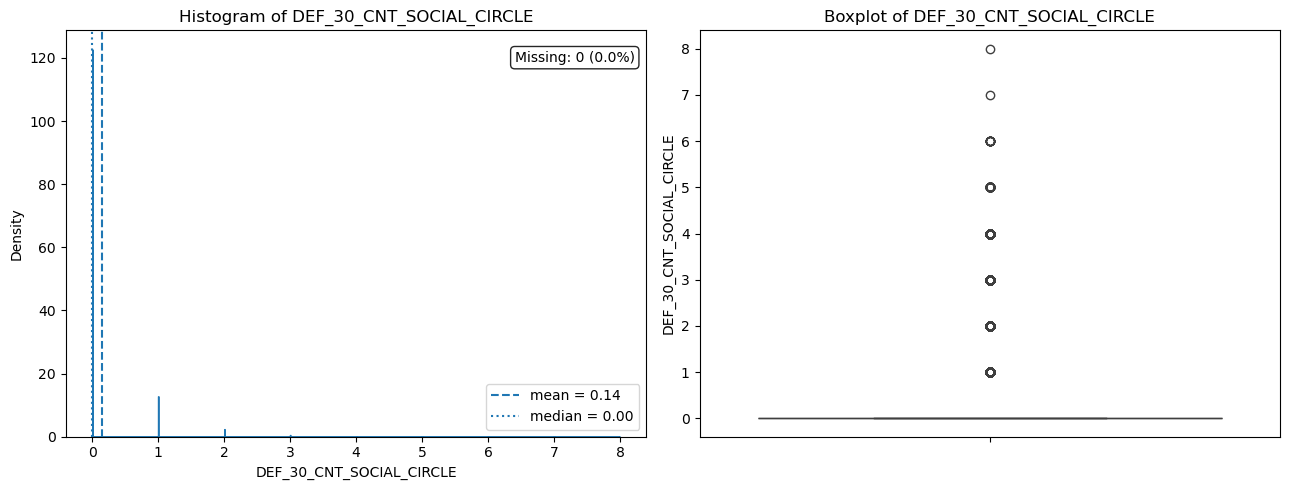

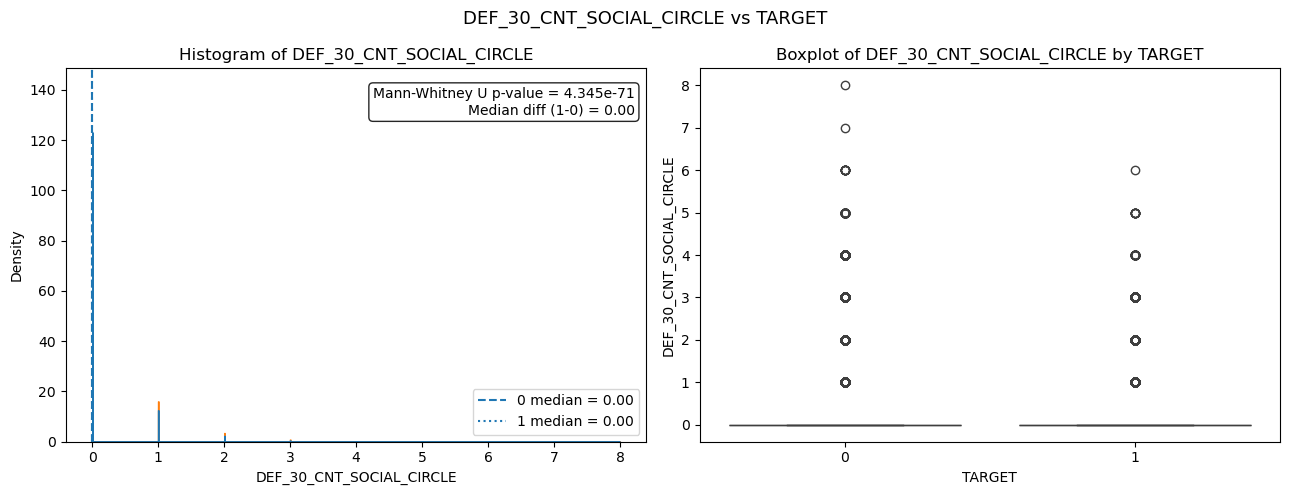

In [49]:
plot_quantitative_distribution(df=app_df[app_df['DEF_30_CNT_SOCIAL_CIRCLE'] < 34], quant_var='DEF_30_CNT_SOCIAL_CIRCLE')
plot_quantitative_vs_binary(df=app_df[app_df['DEF_30_CNT_SOCIAL_CIRCLE'] < 34], quant_var='DEF_30_CNT_SOCIAL_CIRCLE', binary_var='TARGET')

In [ ]:
app_df["DEF_30_CNT_SOCIAL_CIRCLE_missing"] = (app_df["DEF_30_CNT_SOCIAL_CIRCLE"].isna()).astype(int)
app_df["DEF_30_CNT_SOCIAL_CIRCLE_eq_0"] = (app_df["DEF_30_CNT_SOCIAL_CIRCLE"] == 0).astype(int)
app_df["DEF_30_CNT_SOCIAL_CIRCLE_ge_3"] = (app_df["DEF_30_CNT_SOCIAL_CIRCLE"] >= 3).astype(int)

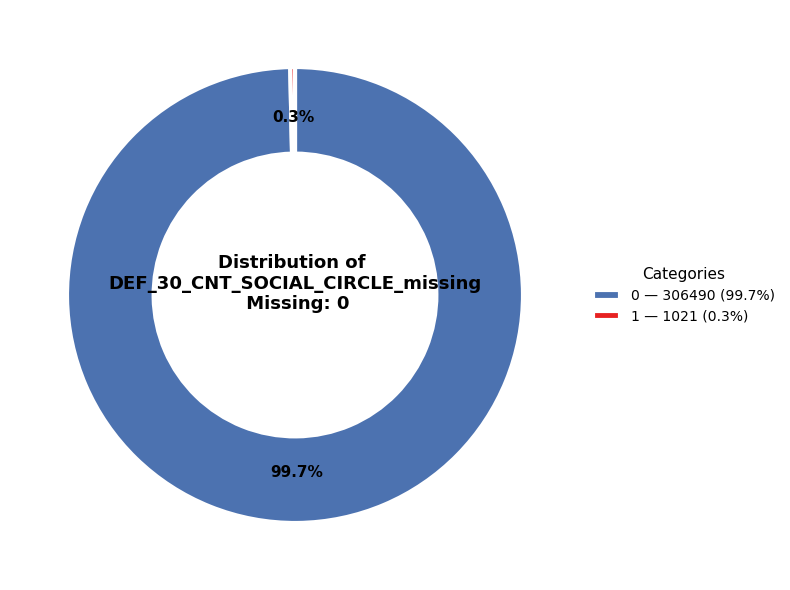

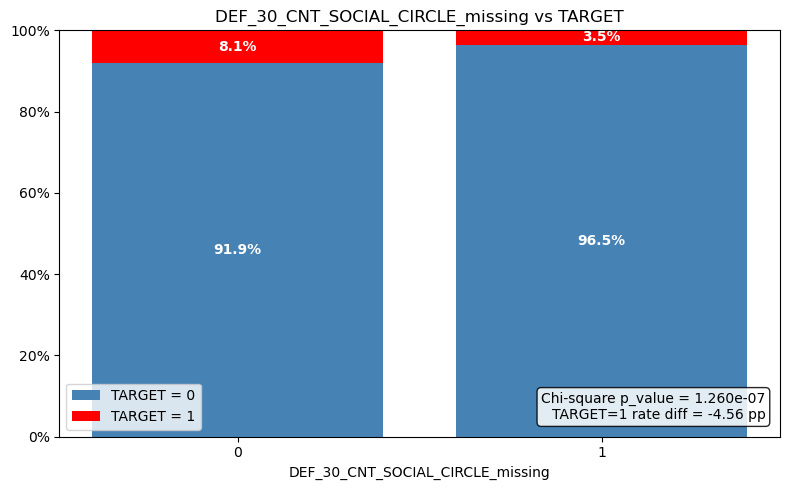

In [51]:
plot_binary_distribution(df=app_df, binary_var='DEF_30_CNT_SOCIAL_CIRCLE_missing')
plot_binary_vs_binary(df=app_df, binary_var='DEF_30_CNT_SOCIAL_CIRCLE_missing', target_var='TARGET')

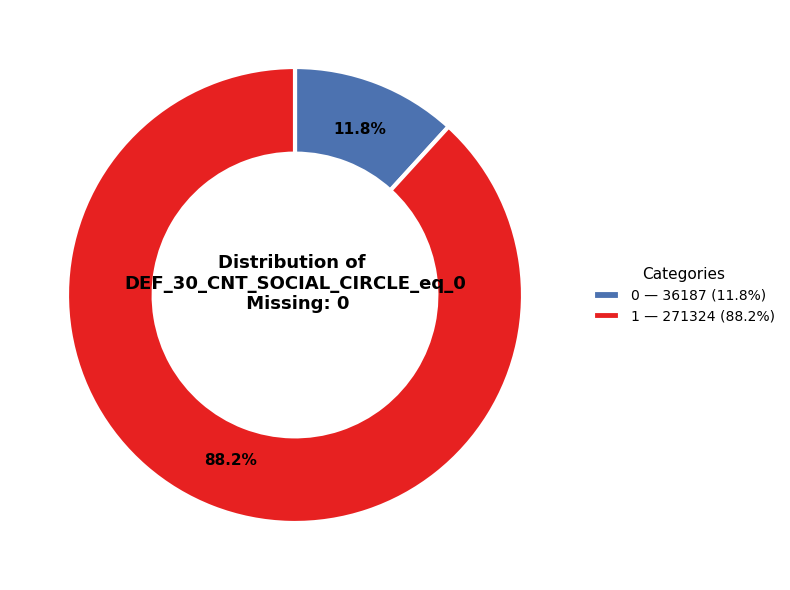

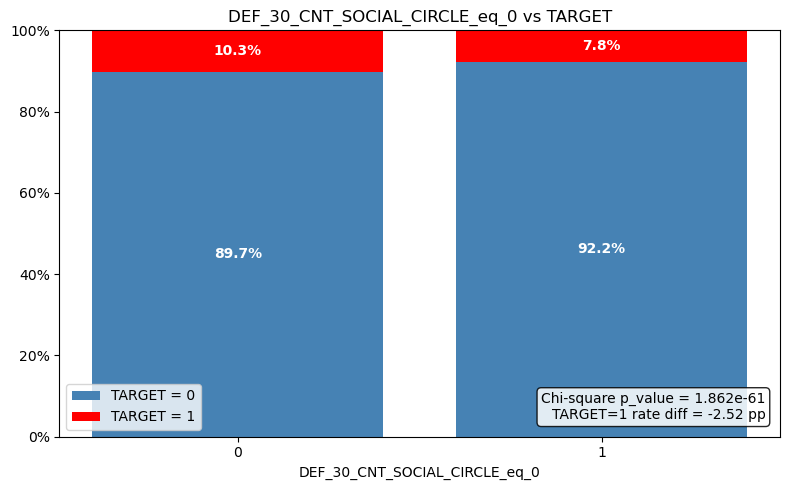

In [52]:
plot_binary_distribution(df=app_df, binary_var='DEF_30_CNT_SOCIAL_CIRCLE_eq_0')
plot_binary_vs_binary(df=app_df, binary_var='DEF_30_CNT_SOCIAL_CIRCLE_eq_0', target_var='TARGET')

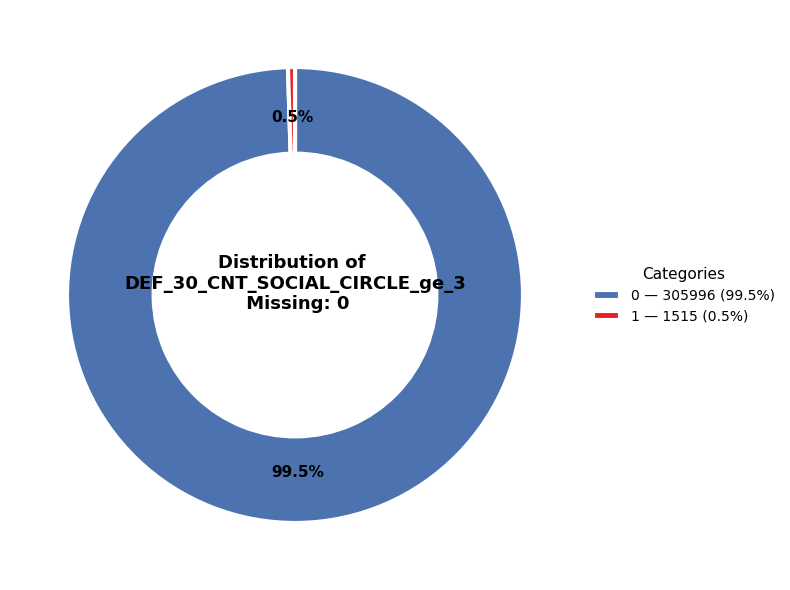

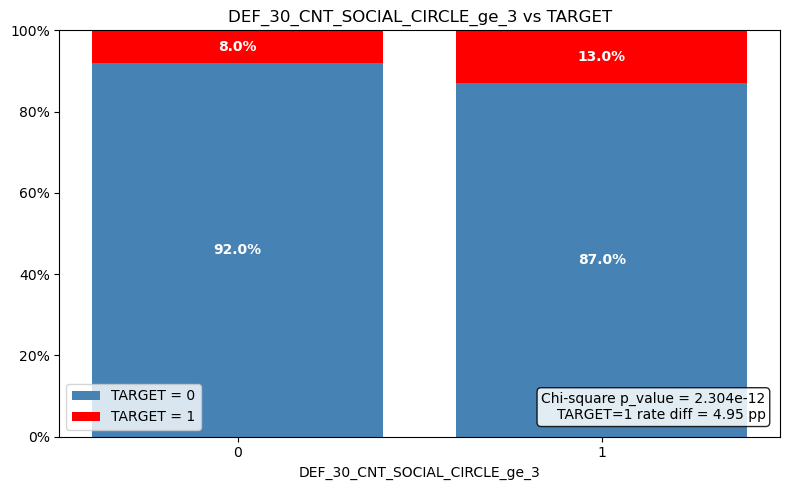

In [53]:
plot_binary_distribution(df=app_df, binary_var='DEF_30_CNT_SOCIAL_CIRCLE_ge_3')
plot_binary_vs_binary(df=app_df, binary_var='DEF_30_CNT_SOCIAL_CIRCLE_ge_3', target_var='TARGET')

In [71]:
app_df['DEF_30_CNT_SOCIAL_CIRCLE_cap_cat'] = np.where(
    app_df['DEF_30_CNT_SOCIAL_CIRCLE'].isin([0,1]),
    app_df['DEF_30_CNT_SOCIAL_CIRCLE'].astype(str),
    np.where(
        app_df['DEF_30_CNT_SOCIAL_CIRCLE'].isna(),
        'Missing',
        '>= 2'
    )
)

app_df['DEF_30_CNT_SOCIAL_CIRCLE_cap_cat'].value_counts()

DEF_30_CNT_SOCIAL_CIRCLE_cap_cat
0.0        271324
1.0         28328
>= 2         6838
Missing      1021
Name: count, dtype: int64

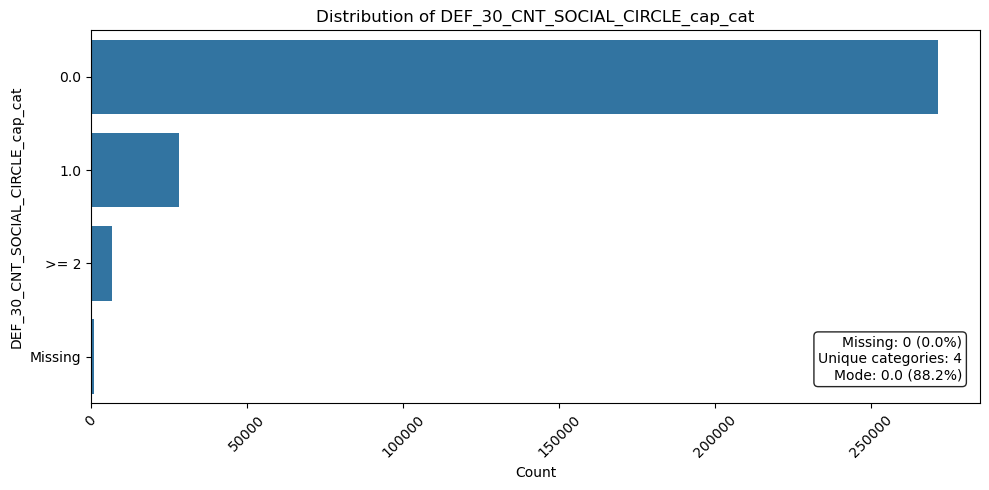

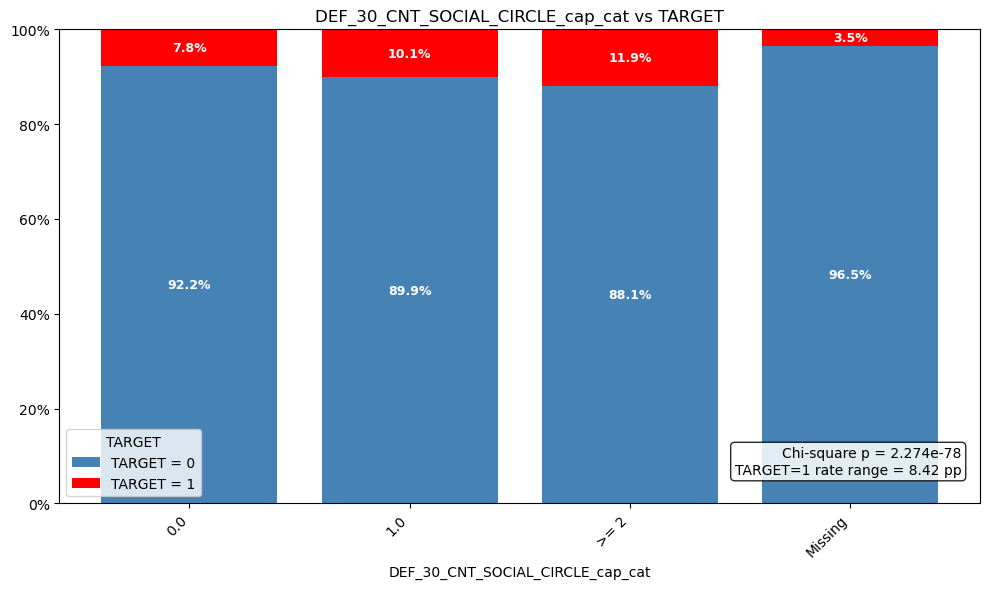

In [72]:
plot_categorical_distribution(df=app_df, cat_var='DEF_30_CNT_SOCIAL_CIRCLE_cap_cat')
plot_categorical_vs_binary(df=app_df, cat_var='DEF_30_CNT_SOCIAL_CIRCLE_cap_cat', target_var='TARGET')

In [98]:
app_df['DEF_30_CNT_SOCIAL_CIRCLE_imp_global_cap'] = np.where(
    app_df['DEF_30_CNT_SOCIAL_CIRCLE'].isin([0,1]),
    app_df['DEF_30_CNT_SOCIAL_CIRCLE'],
    np.where(
        app_df['DEF_30_CNT_SOCIAL_CIRCLE'] >= 2,
        2.0,
        np.where(
            app_df['DEF_30_CNT_SOCIAL_CIRCLE'].isna(),
            app_df['DEF_30_CNT_SOCIAL_CIRCLE'].median(),
            999.0
        )
    )
)
app_df['DEF_30_CNT_SOCIAL_CIRCLE_imp_global_cap'].value_counts()

DEF_30_CNT_SOCIAL_CIRCLE_imp_global_cap
0.0    272345
1.0     28328
2.0      6838
Name: count, dtype: int64

## 3. OBS_60_CNT_SOCIAL_CIRCLE
How many observation of client's social surroundings with observable 60 DPD (days past due) default

In [77]:
print(app_df['OBS_60_CNT_SOCIAL_CIRCLE'].describe())
print(app_df['OBS_60_CNT_SOCIAL_CIRCLE'].value_counts())
print(f"NANs: {app_df['OBS_60_CNT_SOCIAL_CIRCLE'].isna().sum()}")

count    306490.000000
mean          1.405292
std           2.379803
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         344.000000
Name: OBS_60_CNT_SOCIAL_CIRCLE, dtype: float64
OBS_60_CNT_SOCIAL_CIRCLE
0.0      164666
1.0       48870
2.0       29766
3.0       20215
4.0       13946
5.0        9463
6.0        6349
7.0        4344
8.0        2886
9.0        1959
10.0       1335
11.0        837
12.0        620
13.0        401
14.0        238
15.0        166
16.0        137
17.0         73
18.0         49
19.0         44
20.0         30
21.0         28
22.0         20
23.0         13
24.0         12
25.0         11
27.0          5
29.0          2
28.0          1
47.0          1
344.0         1
30.0          1
26.0          1
Name: count, dtype: int64
NANs: 1021


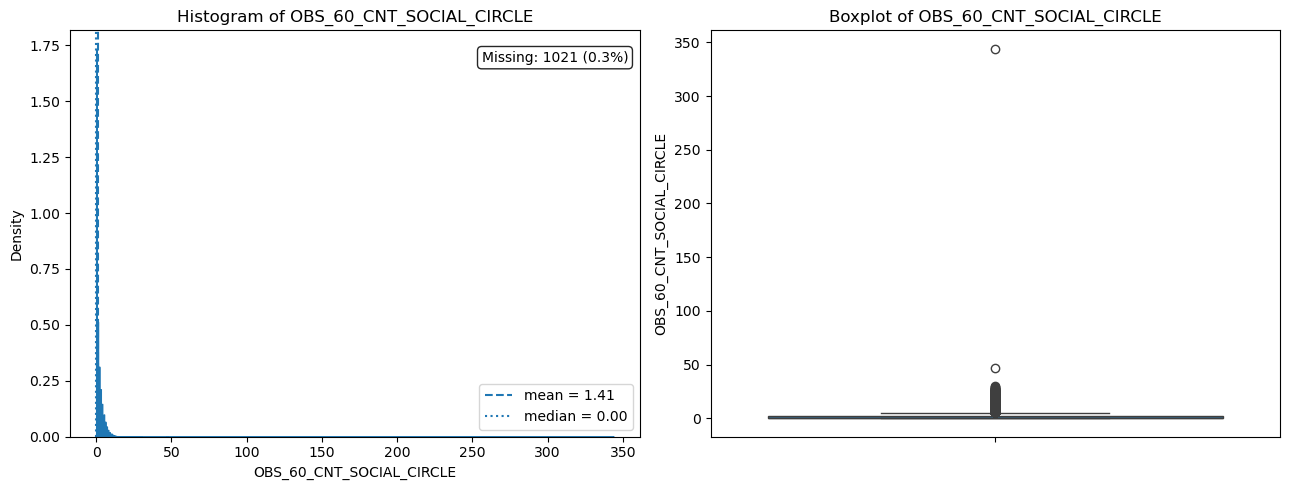

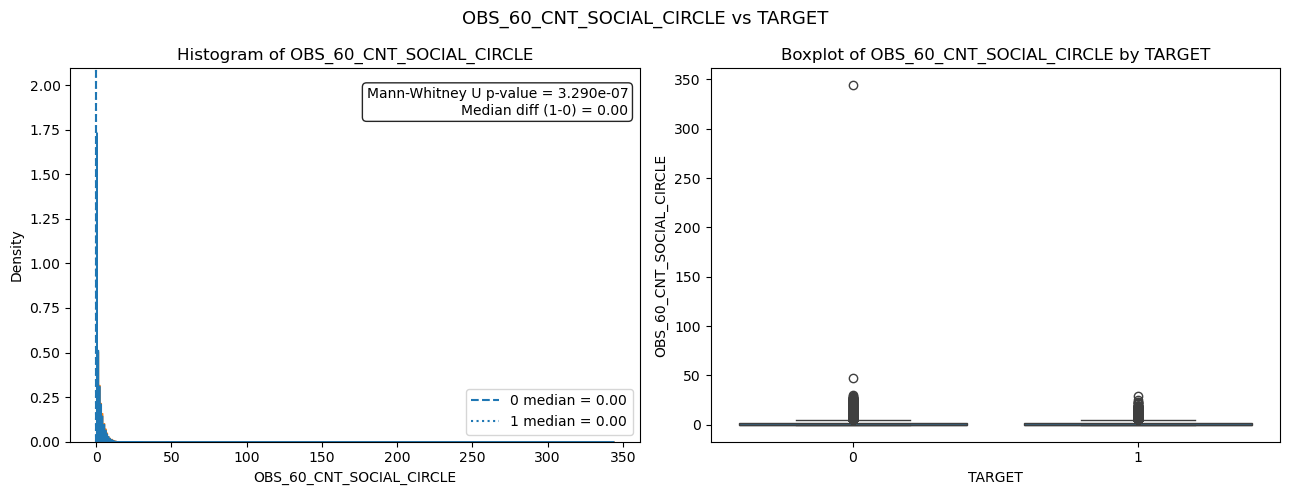

In [78]:
plot_quantitative_distribution(df=app_df, quant_var='OBS_60_CNT_SOCIAL_CIRCLE')
plot_quantitative_vs_binary(df=app_df, quant_var='OBS_60_CNT_SOCIAL_CIRCLE', binary_var='TARGET')

In [84]:
app_df['OBS_60_CNT_SOCIAL_CIRCLE_cap_cat'] = np.where(
    app_df['OBS_60_CNT_SOCIAL_CIRCLE'] == 0,
    '0',
    np.where(
        app_df['OBS_60_CNT_SOCIAL_CIRCLE'].isin([1,2,3,4,5,6,7]),
        app_df['OBS_60_CNT_SOCIAL_CIRCLE'].astype(str),
        np.where(
            app_df['OBS_60_CNT_SOCIAL_CIRCLE'].isna(),
            'Missing',
            np.where(
                app_df['OBS_60_CNT_SOCIAL_CIRCLE'] >= 8,
                '>= 8',
                'Invalid'
            )
        )
    )
)


app_df['OBS_60_CNT_SOCIAL_CIRCLE_cap_cat'].value_counts()

OBS_60_CNT_SOCIAL_CIRCLE_cap_cat
0          164666
1.0         48870
2.0         29766
3.0         20215
4.0         13946
5.0          9463
>= 8         8871
6.0          6349
7.0          4344
Missing      1021
Name: count, dtype: int64

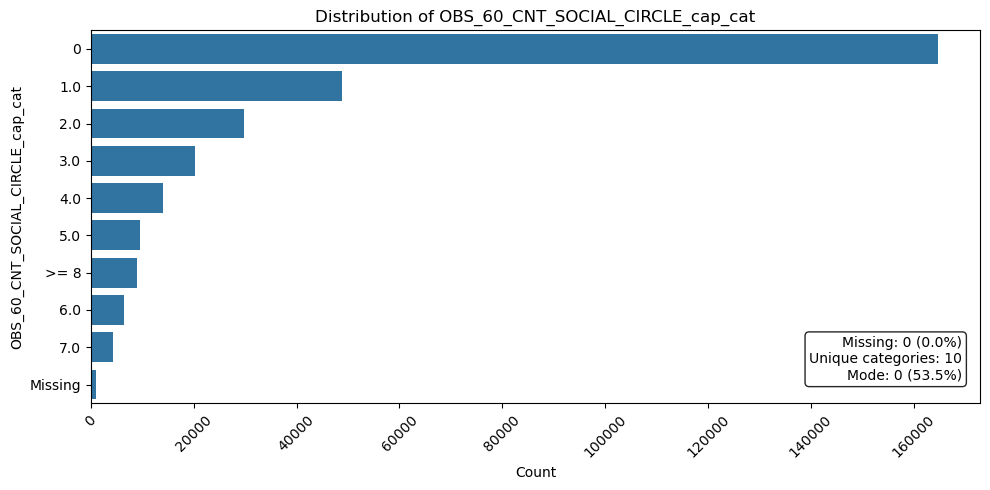

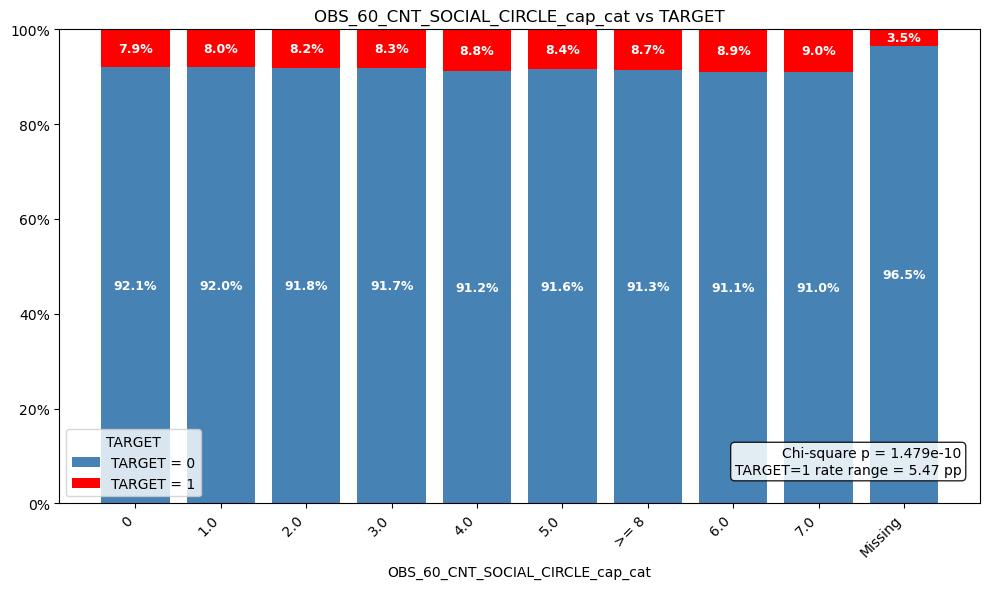

In [85]:
plot_categorical_distribution(df=app_df, cat_var='OBS_60_CNT_SOCIAL_CIRCLE_cap_cat')
plot_categorical_vs_binary(df=app_df, cat_var='OBS_60_CNT_SOCIAL_CIRCLE_cap_cat', target_var='TARGET')

In [90]:
app_df['OBS_60_CNT_SOCIAL_CIRCLE_cap_cat'] = np.where(
    app_df['OBS_60_CNT_SOCIAL_CIRCLE'] == 0,
    '0',
    np.where(
        app_df['OBS_60_CNT_SOCIAL_CIRCLE'].isin([1,2,3]),
        '1-3',
        np.where(
            app_df['OBS_60_CNT_SOCIAL_CIRCLE'].isna(),
            'Missing',
            np.where(
                app_df['OBS_60_CNT_SOCIAL_CIRCLE'] >= 4,
                '>= 4',
                'Invalid'
            )
        )
    )
)


app_df['OBS_60_CNT_SOCIAL_CIRCLE_cap_cat'].value_counts()

OBS_60_CNT_SOCIAL_CIRCLE_cap_cat
0          164666
1-3         98851
>= 4        42973
Missing      1021
Name: count, dtype: int64

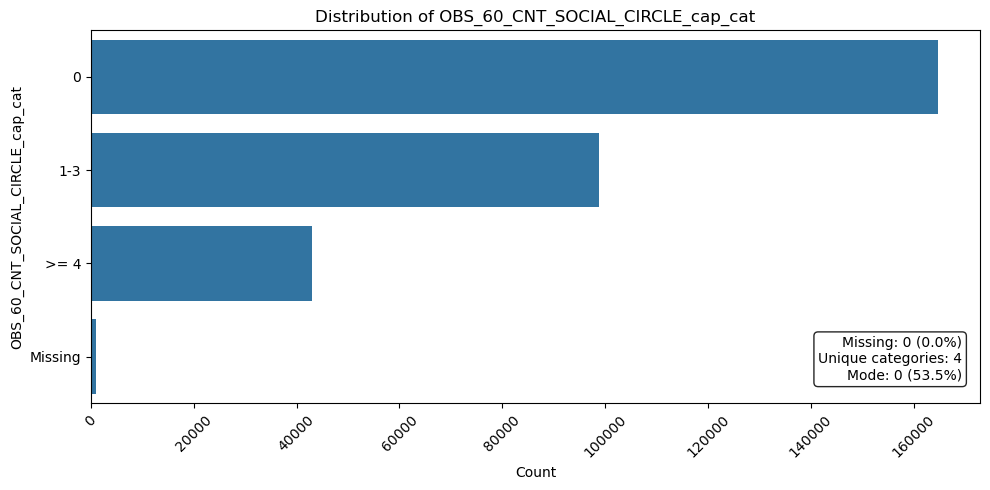

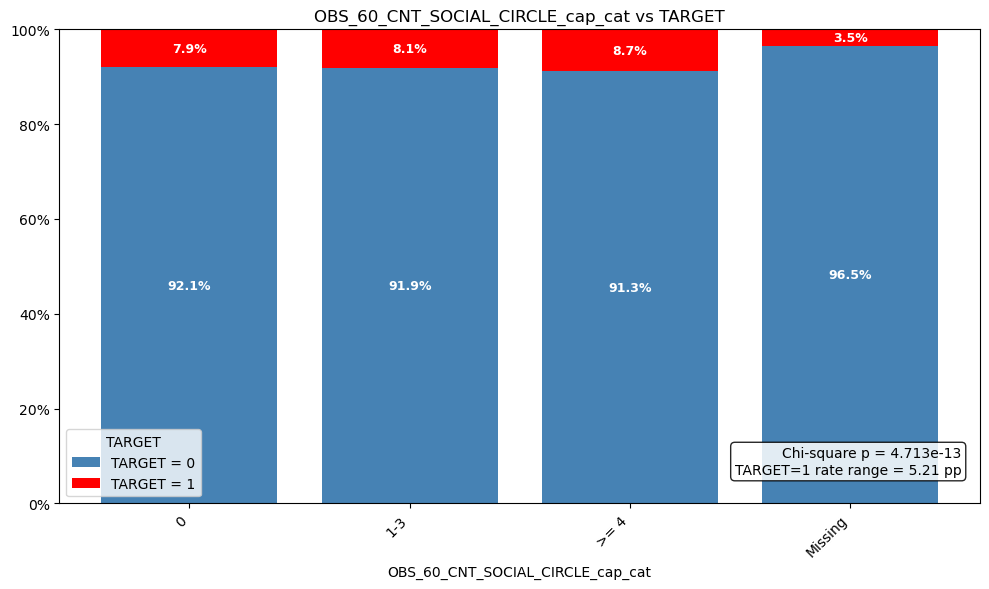

In [91]:
plot_categorical_distribution(df=app_df, cat_var='OBS_60_CNT_SOCIAL_CIRCLE_cap_cat')
plot_categorical_vs_binary(df=app_df, cat_var='OBS_60_CNT_SOCIAL_CIRCLE_cap_cat', target_var='TARGET')

In [97]:
app_df['OBS_60_CNT_SOCIAL_CIRCLE_imp_global_cap'] = np.where(
    app_df['OBS_60_CNT_SOCIAL_CIRCLE'].isin([0,1,2,3]),
    app_df['OBS_60_CNT_SOCIAL_CIRCLE'],
    np.where(
        app_df['OBS_60_CNT_SOCIAL_CIRCLE'] >= 4,
        4.0,
        np.where(
            app_df['OBS_60_CNT_SOCIAL_CIRCLE'].isna(),
            app_df['OBS_60_CNT_SOCIAL_CIRCLE'].median(),
            999.0
        )
    )
)
app_df['OBS_60_CNT_SOCIAL_CIRCLE_imp_global_cap'].value_counts()

OBS_60_CNT_SOCIAL_CIRCLE_imp_global_cap
0.0    165687
1.0     48870
4.0     42973
2.0     29766
3.0     20215
Name: count, dtype: int64

The categorical version is probably the best for differentating between risk ratios.

## 4. DEF_60_CNT_SOCIAL_CIRCLE
How many observation of client's social surroundings defaulted on 60 (days past due) DPD

In [92]:
print(app_df['DEF_60_CNT_SOCIAL_CIRCLE'].describe())
print(f"NANs: {app_df['DEF_60_CNT_SOCIAL_CIRCLE'].isna().sum()}")
print(app_df['DEF_60_CNT_SOCIAL_CIRCLE'].value_counts())

count    306490.000000
mean          0.100049
std           0.362291
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          24.000000
Name: DEF_60_CNT_SOCIAL_CIRCLE, dtype: float64
NANs: 1021
DEF_60_CNT_SOCIAL_CIRCLE
0.0     280721
1.0      21841
2.0       3170
3.0        598
4.0        135
5.0         20
6.0          3
7.0          1
24.0         1
Name: count, dtype: int64


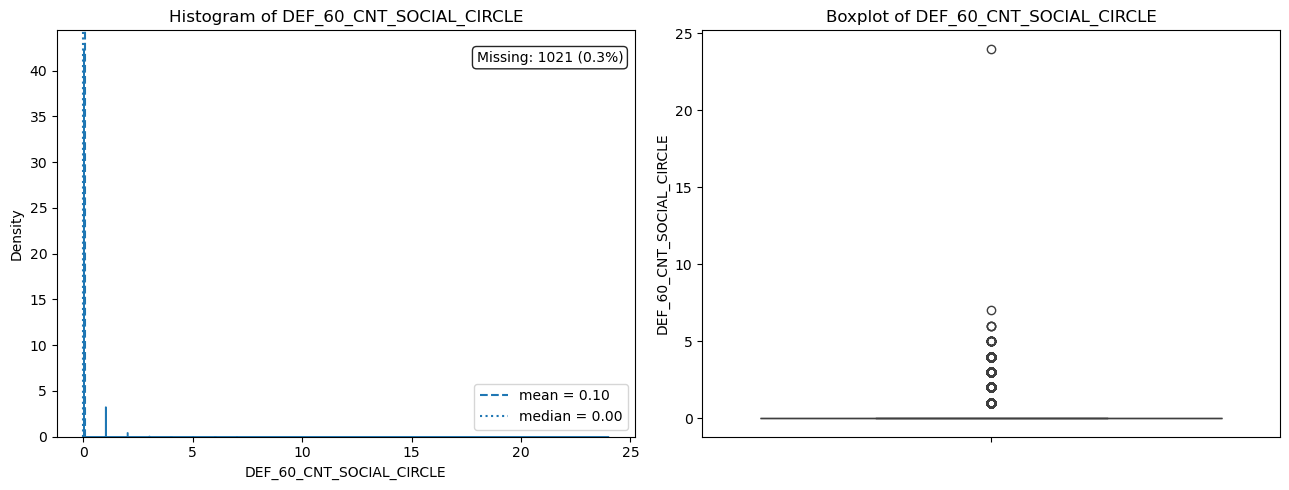

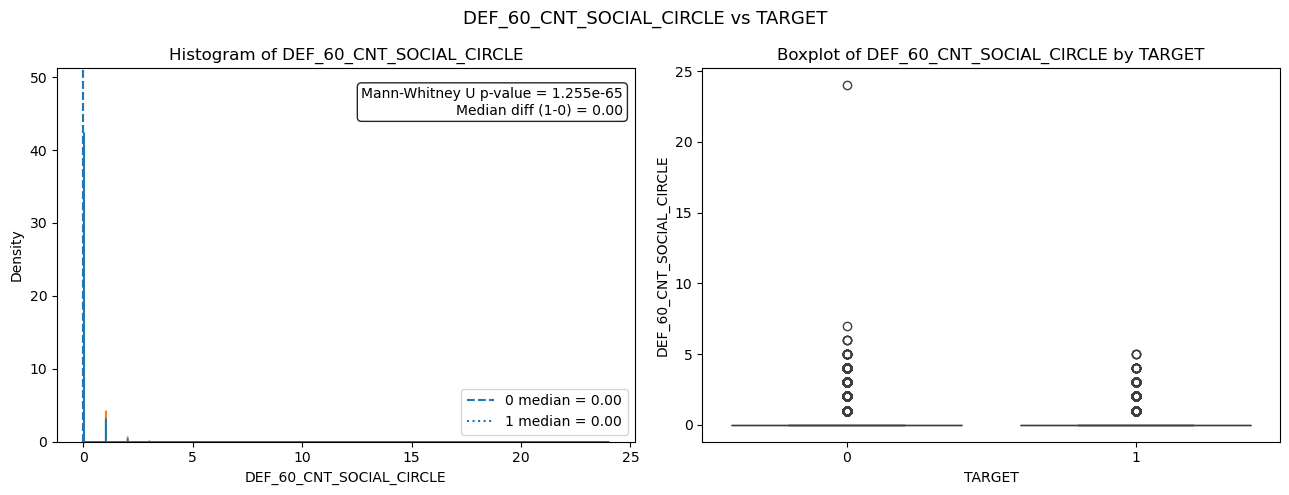

In [93]:
plot_quantitative_distribution(df=app_df, quant_var='DEF_60_CNT_SOCIAL_CIRCLE')
plot_quantitative_vs_binary(df=app_df, quant_var='DEF_60_CNT_SOCIAL_CIRCLE', binary_var='TARGET')

In [94]:
app_df['DEF_60_CNT_SOCIAL_CIRCLE_cap_cat'] = np.where(
    app_df['DEF_60_CNT_SOCIAL_CIRCLE'].isin([0,1]),
    app_df['DEF_60_CNT_SOCIAL_CIRCLE'].astype(str),
    np.where(
        app_df['DEF_60_CNT_SOCIAL_CIRCLE'] >= 2,
        '>= 2',
        np.where(
            app_df['DEF_60_CNT_SOCIAL_CIRCLE'].isna(),
            'Missing',
            'Invalid'
        )
    )
)
app_df['DEF_60_CNT_SOCIAL_CIRCLE_cap_cat'].value_counts()

DEF_60_CNT_SOCIAL_CIRCLE_cap_cat
0.0        280721
1.0         21841
>= 2         3928
Missing      1021
Name: count, dtype: int64

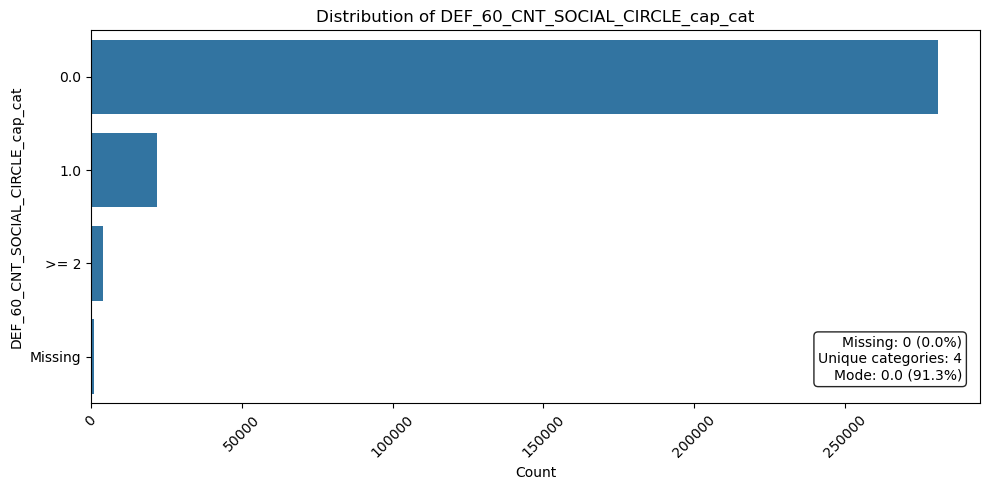

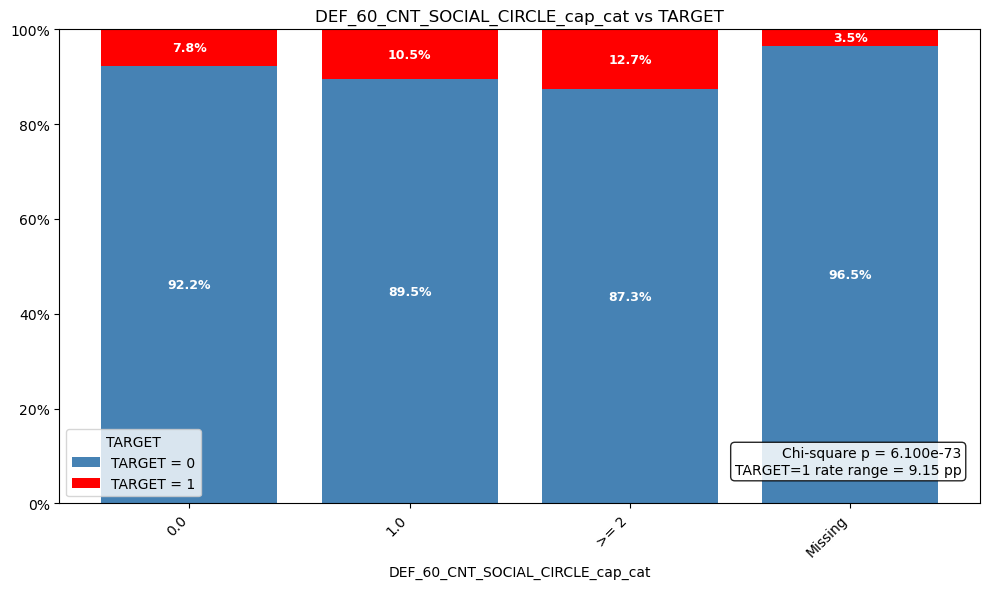

In [95]:
plot_categorical_distribution(df=app_df, cat_var='DEF_60_CNT_SOCIAL_CIRCLE_cap_cat')
plot_categorical_vs_binary(df=app_df, cat_var='DEF_60_CNT_SOCIAL_CIRCLE_cap_cat', target_var='TARGET')

In [96]:
app_df['DEF_60_CNT_SOCIAL_CIRCLE_imp_global_cap'] = np.where(
    app_df['DEF_60_CNT_SOCIAL_CIRCLE'].isin([0,1]),
    app_df['DEF_60_CNT_SOCIAL_CIRCLE'],
    np.where(
        app_df['DEF_60_CNT_SOCIAL_CIRCLE'] >= 2,
        2.0,
        np.where(
            app_df['DEF_60_CNT_SOCIAL_CIRCLE'].isna(),
            app_df['DEF_60_CNT_SOCIAL_CIRCLE'].median(),
            999.0
        )
    )
)
app_df['DEF_60_CNT_SOCIAL_CIRCLE_imp_global_cap'].value_counts()

DEF_60_CNT_SOCIAL_CIRCLE_imp_global_cap
0.0    281742
1.0     21841
2.0      3928
Name: count, dtype: int64

## 5. Application social surrounding data summary
Variables that should be used as predictors
- OBS_30_CNT_SOCIAL_CIRCLE_cap_cat
- OBS_30_CNT_SOCIAL_CIRCLE_imp_global_cap
- DEF_30_CNT_SOCIAL_CIRCLE_cap_cat
- DEF_30_CNT_SOCIAL_CIRCLE_imp_global_cap
- OBS_60_CNT_SOCIAL_CIRCLE_cap_cat
- OBS_60_CNT_SOCIAL_CIRCLE_imp_global_cap
- DEF_60_CNT_SOCIAL_CIRCLE_cap_cat
- DEF_60_CNT_SOCIAL_CIRCLE_imp_global_cap